# FORTIFY leakage topology and high-leakage fanin analysis

This notebook reads `parents.txt` and `all_signal_leakage.csv`, builds a NetworkX graph, assigns topological levels using `nx.topological_generations`, and plots leakage against topological level.

It also extracts raw transitive fanin cones for selected high-leakage output-like signals, overlays those paths, caches the fanin data, and prints/saves statistics comparing those high-leakage paths against the rest of the graph.


In [21]:
# -----------------------------
# User configuration
# -----------------------------
from pathlib import Path

PROJECT_ROOT = Path("fortify")
BENCHMARKS_DIR = PROJECT_ROOT / "Benchmarks"
RESULTS_ROOT = PROJECT_ROOT / "results"
RUN_NAME = "aes"               # e.g. "demo", "aes", "2026-..."
OUTPUT_ROOT = PROJECT_ROOT / "analysis_outputs" / "leakage_topology"

# Use the full list for final runs. For quick testing, replace with [100, 200].
AES_SIZES = [100, 200, 700, 800, 1100, 1200, 1600, 1700]
# AES_SIZES = [100,200]

DESIGN_NAME_TEMPLATE = "aes{size}"               # produces aes100
RESULT_SUBDIR_TEMPLATE = "{design}_recon"        # e.g. results/aes/aes100_recon
VERILOG_FILE_TEMPLATE = "AES{size}.v"

PARENTS_FILENAME = "parents.txt"
LEAKAGE_FILENAME = "all_signal_leakage.csv"

# Target selection.
# "threshold": select output-like signals with leakage > LEAKAGE_THRESHOLD.
# "top_k_outputs": ignore threshold and take the top MAX_TARGETS_PER_DESIGN output-like signals.
# "threshold_or_top_k": use threshold; if no targets survive, fall back to top-k.
TARGET_SELECTION_MODE = "threshold_or_top_k"
LEAKAGE_THRESHOLD = 1e-8
TARGET_OUTPUT_PREFIXES = ["top.Capacitance", "top.out"]
# TARGET_OUTPUT_PREFIXES = None   # allow any signal as a target

# Maximum number of selected target signals per design for which fanin lines are drawn.
# Set to None to use all selected targets.
MAX_TARGETS_PER_DESIGN = 5

# Drawing controls.
MAX_FANIN_EDGES_DRAWN_PER_DESIGN = 50000
SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS = True
SAVE_CSVS = True
SAVE_PICKLES = True

X_JITTER = 0.0       # keep 0.0 if you want exact integer topological levels on x-axis
POINT_ALPHA_ALL = 0.08
POINT_ALPHA_CONE = 0.65

FANIN_LINE_WIDTH = 1.6
FANIN_LINE_ALPHA = 0.65

# High-contrast categorical colors for combined multi-design plots.
DESIGN_COLORS = [
    "#e41a1c",  # red
    "#377eb8",  # blue
    "#4daf4a",  # green
    "#984ea3",  # purple
    "#ff7f00",  # orange
    "#a65628",  # brown
    "#f781bf",  # pink
    "#17becf",  # cyan
    "#000000",  # black
    "#999999",  # gray
]
DESIGN_LINESTYLES = ["solid", "dashed", "dashdot", "dotted"]

# Statistics controls.
LEAKAGE_EPS = 1e-30
STATS_QUANTILES = [0.0, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1.0]

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

DESIGN_SPECS = []
for size in AES_SIZES:
    design = DESIGN_NAME_TEMPLATE.format(size=size)
    DESIGN_SPECS.append({
        "size": size,
        "design": design,
        "verilog_path": BENCHMARKS_DIR / VERILOG_FILE_TEMPLATE.format(size=size),
        "result_dir": RESULTS_ROOT / RUN_NAME / RESULT_SUBDIR_TEMPLATE.format(design=design, size=size),
    })

DESIGN_SPECS[:2]

# -- STATS --
# fanin median leakage
# rest median leakage
# fanin p90 leakage
# rest p90 leakage
# AUC P(fanin leakage > rest leakage)
# median same-level percentile of fanin nodes
# median same-level percentile of selected targets


[{'size': 100,
  'design': 'aes100',
  'verilog_path': PosixPath('fortify/Benchmarks/AES100.v'),
  'result_dir': PosixPath('fortify/results/aes/aes100_recon')},
 {'size': 200,
  'design': 'aes200',
  'verilog_path': PosixPath('fortify/Benchmarks/AES200.v'),
  'result_dir': PosixPath('fortify/results/aes/aes200_recon')}]

In [22]:
# -----------------------------
# Imports
# -----------------------------
import ast
import math
import pickle
import hashlib
from collections import deque, defaultdict

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from IPython.display import display

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_columns", 100)


In [23]:
# -----------------------------
# Parsers and graph utilities
# -----------------------------

def read_parents_txt(path):
    """
    Parse parents.txt lines of the form:
        child_node: ['parent0', 'parent1', ...]

    Signal names contain colons inside bit slices, so this parser keeps moving
    the split point left until the RHS parses as a Python list.
    """
    path = Path(path)
    parents = {}

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for raw in f:
            line = raw.strip()
            if not line or line.startswith("#") or ":" not in line:
                continue

            lhs, sep, rhs = line.rpartition(":")
            if not sep:
                continue

            candidate = None
            cur_lhs, cur_rhs = lhs, rhs

            while True:
                try:
                    val = ast.literal_eval(cur_rhs.strip())
                    if isinstance(val, list):
                        candidate = (cur_lhs.strip(), val)
                        break
                except Exception:
                    pass

                pos = cur_lhs.rfind(":")
                if pos < 0:
                    break
                cur_rhs = cur_lhs[pos + 1:] + ":" + cur_rhs
                cur_lhs = cur_lhs[:pos]

            if candidate is None:
                continue

            child, plist = candidate
            parents[child] = [p for p in plist if isinstance(p, str) and p]

    return parents


def build_networkx_graph_from_parents(parents, extra_nodes=None):
    """Build raw directed graph. Edges are parent -> child."""
    G = nx.DiGraph()

    for child, plist in parents.items():
        G.add_node(child)
        for parent in plist:
            G.add_node(parent)
            G.add_edge(parent, child)

    if extra_nodes:
        G.add_nodes_from(str(n) for n in extra_nodes if isinstance(n, str) and n)

    return G


def load_leakage_csv(path):
    """
    Returns:
        leakage_by_node[node] = {
            leakage, best_ref, actual_signal, actual_ref, pbv, prior
        }

    Supports both:
        all_signal_leakage.csv
        all_signal_leakage_by_ref.csv
    """
    path = Path(path)
    df = pd.read_csv(path)

    colmap = {c.lower(): c for c in df.columns}
    signal_col = colmap.get("signal")
    ref_col = colmap.get("ref")
    actual_signal_col = colmap.get("actualsignal") or colmap.get("actual_signal")
    actual_ref_col = colmap.get("actualref") or colmap.get("actual_ref")
    leakage_col = colmap.get("leakage_pbv")
    pbv_col = colmap.get("pbv")
    prior_col = colmap.get("prior")

    if signal_col is None or leakage_col is None:
        raise ValueError(f"{path} must contain at least Signal and Leakage_PBV columns")

    df[leakage_col] = pd.to_numeric(df[leakage_col], errors="coerce").fillna(0.0)
    if pbv_col:
        df[pbv_col] = pd.to_numeric(df[pbv_col], errors="coerce")
    if prior_col:
        df[prior_col] = pd.to_numeric(df[prior_col], errors="coerce")

    leakage_by_node = {}

    def add_row(node_name, row):
        if not isinstance(node_name, str) or not node_name or node_name == "nan":
            return

        leakage = float(row[leakage_col])
        old = leakage_by_node.get(node_name)
        if old is not None and old["leakage"] >= leakage:
            return

        leakage_by_node[node_name] = {
            "leakage": leakage,
            "best_ref": str(row[ref_col]) if ref_col else "",
            "actual_signal": str(row[actual_signal_col]) if actual_signal_col else str(row[signal_col]),
            "actual_ref": str(row[actual_ref_col]) if actual_ref_col else (str(row[ref_col]) if ref_col else ""),
            "pbv": float(row[pbv_col]) if pbv_col and not pd.isna(row[pbv_col]) else math.nan,
            "prior": float(row[prior_col]) if prior_col and not pd.isna(row[prior_col]) else math.nan,
        }

    for _, row in df.iterrows():
        add_row(str(row[signal_col]), row)
        if actual_signal_col:
            add_row(str(row[actual_signal_col]), row)

    return leakage_by_node, df


def graph_levels_with_networkx(G):
    """
    Assign topological levels using NetworkX.

    If G is a DAG:
        use nx.topological_generations(G) directly.

    If G has cycles:
        use nx.condensation(G), which is a DAG, then use nx.topological_generations
        on the condensation DAG. Nodes in the same SCC get the same level.
    """
    if nx.is_directed_acyclic_graph(G):
        level_by_node = {}
        generations = []

        for level, nodes in enumerate(nx.topological_generations(G)):
            nodes = list(nodes)
            generations.append(nodes)
            for n in nodes:
                level_by_node[n] = level

        scc_size_by_node = {n: 1 for n in G.nodes}
        return level_by_node, scc_size_by_node, generations, G

    C = nx.condensation(G)
    node_to_comp = C.graph["mapping"]

    members_by_comp = defaultdict(list)
    for n, comp in node_to_comp.items():
        members_by_comp[comp].append(n)

    comp_level = {}
    generations = []

    for level, comps in enumerate(nx.topological_generations(C)):
        level_nodes = []
        for comp in comps:
            comp_level[comp] = level
            level_nodes.extend(members_by_comp.get(comp, []))
        generations.append(level_nodes)

    level_by_node = {n: comp_level[comp] for n, comp in node_to_comp.items()}
    scc_size_by_node = {n: len(members_by_comp[comp]) for n, comp in node_to_comp.items()}

    return level_by_node, scc_size_by_node, generations, C


def node_matches_prefix(node, prefixes):
    if prefixes is None:
        return True
    return any(str(node).startswith(prefix) for prefix in prefixes)


def stable_jitter(node, jitter):
    if not jitter or jitter <= 0:
        return 0.0
    h = hashlib.md5(str(node).encode("utf-8")).hexdigest()
    v = int(h[:8], 16) / 0xFFFFFFFF
    return (v - 0.5) * float(jitter)


def add_leakage_percentiles(node_df):
    """
    Adds threshold-free ranking signals that help see whether a node is unusual
    globally and relative to other nodes in the same topological level.
    """
    df = node_df.copy()
    df["leakage_percentile_global"] = math.nan
    df["leakage_percentile_same_level"] = math.nan
    df["leakage_log10"] = math.nan

    mask = df["has_leakage"] == True
    if mask.any():
        df.loc[mask, "leakage_percentile_global"] = df.loc[mask, "leakage"].rank(pct=True, method="average")
        df.loc[mask, "leakage_log10"] = (df.loc[mask, "leakage"].clip(lower=LEAKAGE_EPS)).map(math.log10)

        df.loc[mask, "leakage_percentile_same_level"] = (
            df.loc[mask]
              .groupby("topological_level")["leakage"]
              .rank(pct=True, method="average")
        )

    output_like = mask & df["node"].map(lambda n: node_matches_prefix(n, TARGET_OUTPUT_PREFIXES))
    df["output_like_robust_z"] = math.nan

    if output_like.sum() >= 2:
        vals = df.loc[output_like, "leakage"].astype(float)
        med = vals.median()
        mad = (vals - med).abs().median()
        denom = 1.4826 * mad if mad > 0 else vals.std(ddof=0)
        if not denom or pd.isna(denom) or denom == 0:
            denom = LEAKAGE_EPS
        df.loc[output_like, "output_like_robust_z"] = (vals - med) / denom

    return df


def build_node_dataframe(G, leakage_by_node, design):
    level_by_node, scc_size_by_node, generations, level_dag = graph_levels_with_networkx(G)

    rows = []
    for n in G.nodes:
        leak = leakage_by_node.get(n)
        rows.append({
            "design": design,
            "node": n,
            "topological_level": int(level_by_node.get(n, -1)),
            "scc_size": int(scc_size_by_node.get(n, 1)),
            "indegree": int(G.in_degree(n)),
            "outdegree": int(G.out_degree(n)),
            "has_leakage": leak is not None,
            "leakage": leak["leakage"] if leak else math.nan,
            "plot_leakage": leak["leakage"] if leak else 0.0,
            "best_ref": leak["best_ref"] if leak else "",
            "actual_signal": leak["actual_signal"] if leak else "",
            "actual_ref": leak["actual_ref"] if leak else "",
            "pbv": leak["pbv"] if leak else math.nan,
            "prior": leak["prior"] if leak else math.nan,
        })

    df = pd.DataFrame(rows)
    df = df.sort_values(["topological_level", "node"]).reset_index(drop=True)
    df = add_leakage_percentiles(df)
    return df, generations, level_dag


In [24]:
# -----------------------------
# Target selection, fanin cone extraction, and cached fanin annotations
# -----------------------------

def select_high_leakage_targets(node_df, threshold, prefixes=None, max_targets=None, mode="threshold_or_top_k"):
    """
    Select target output-like nodes.

    mode="threshold":
        Select nodes whose leakage exceeds threshold.

    mode="top_k_outputs":
        Ignore threshold and take the top max_targets output-like nodes.

    mode="threshold_or_top_k":
        Use threshold first. If nothing survives, fall back to top-k.
    """
    cand = node_df[
        (node_df["has_leakage"] == True)
        & (node_df["node"].map(lambda n: node_matches_prefix(n, prefixes)))
    ].copy()

    cand = cand.sort_values("leakage", ascending=False)

    if mode == "top_k_outputs":
        selected = cand.copy()
    elif mode == "threshold":
        selected = cand[cand["leakage"] > threshold].copy()
    elif mode == "threshold_or_top_k":
        selected = cand[cand["leakage"] > threshold].copy()
        if selected.empty:
            selected = cand.copy()
    else:
        raise ValueError(f"Unknown TARGET_SELECTION_MODE: {mode}")

    if max_targets is not None:
        selected = selected.head(int(max_targets))

    return selected["node"].tolist(), selected


def compute_fanin_artifacts(G, targets):
    """
    Compute raw transitive fanin cones using the original graph, not the
    condensation DAG. This keeps all actual parent->child edges.

    Returns:
        cone_nodes: set of all nodes in selected target fanin cones
        cone_edges: set of parent->child edges inside those cones
        min_distance_to_target: node -> minimum reverse distance to any selected target
        targets_reached: node -> number of selected targets reachable from that node
    """
    targets = [t for t in targets if t in G]
    cone_nodes = set(targets)
    cone_edges = set()
    min_distance_to_target = {t: 0 for t in targets}
    reached_targets = defaultdict(set)

    for target in targets:
        q = deque([(target, 0)])
        visited = {target}

        while q:
            child, dist = q.popleft()
            cone_nodes.add(child)
            reached_targets[child].add(target)

            if child not in min_distance_to_target or dist < min_distance_to_target[child]:
                min_distance_to_target[child] = dist

            for parent in G.predecessors(child):
                cone_edges.add((parent, child))

                if parent not in visited:
                    visited.add(parent)
                    q.append((parent, dist + 1))

    targets_reached = {n: len(ts) for n, ts in reached_targets.items()}
    return cone_nodes, cone_edges, min_distance_to_target, targets_reached


def annotate_fanin_on_node_df(node_df, targets, cone_nodes, min_distance_to_target, targets_reached):
    df = node_df.copy()
    target_set = set(targets)

    df["is_selected_target"] = df["node"].isin(target_set)
    df["in_selected_fanin_cone"] = df["node"].isin(cone_nodes)
    df["fanin_min_distance_to_target"] = df["node"].map(min_distance_to_target).fillna(-1).astype(int)
    df["fanin_targets_reached"] = df["node"].map(targets_reached).fillna(0).astype(int)

    return df


def add_plot_x(node_df, jitter=0.0):
    df = node_df.copy()
    df["x"] = df["topological_level"].astype(float)
    if jitter and jitter > 0:
        df["x"] = df["x"] + df["node"].map(lambda n: stable_jitter(n, jitter))
    return df


def make_line_segments(plot_df, edges, max_edges=None):
    coord = {
        row.node: (float(row.x), float(row.plot_leakage))
        for row in plot_df.itertuples(index=False)
    }

    segments = []
    missing = 0

    for parent, child in sorted(edges):
        if parent not in coord or child not in coord:
            missing += 1
            continue
        segments.append([coord[parent], coord[child]])
        if max_edges is not None and len(segments) >= int(max_edges):
            break

    return segments, missing


def build_fanin_edges_dataframe(node_df, cone_edges):
    lookup = node_df.set_index("node")
    rows = []

    for parent, child in sorted(cone_edges):
        if parent in lookup.index:
            p = lookup.loc[parent]
            parent_level = int(p["topological_level"])
            parent_leakage = float(p["plot_leakage"])
        else:
            parent_level = math.nan
            parent_leakage = math.nan

        if child in lookup.index:
            c = lookup.loc[child]
            child_level = int(c["topological_level"])
            child_leakage = float(c["plot_leakage"])
        else:
            child_level = math.nan
            child_leakage = math.nan

        rows.append({
            "parent": parent,
            "child": child,
            "parent_level": parent_level,
            "child_level": child_level,
            "parent_plot_leakage": parent_leakage,
            "child_plot_leakage": child_leakage,
            "delta_level": child_level - parent_level if not pd.isna(parent_level) and not pd.isna(child_level) else math.nan,
            "delta_plot_leakage": child_leakage - parent_leakage if not pd.isna(parent_leakage) and not pd.isna(child_leakage) else math.nan,
        })

    return pd.DataFrame(rows)


In [25]:
# -----------------------------
# Distribution statistics and profile utilities
# -----------------------------

def summarize_values(series, prefix):
    vals = pd.to_numeric(series, errors="coerce").dropna()
    out = {
        f"{prefix}_n": int(len(vals)),
    }

    if vals.empty:
        for k in ["mean", "std", "min", "p25", "median", "p75", "p90", "p95", "p99", "max", "positive_log10_mean"]:
            out[f"{prefix}_{k}"] = math.nan
        return out

    q = vals.quantile(STATS_QUANTILES)
    out.update({
        f"{prefix}_mean": float(vals.mean()),
        f"{prefix}_std": float(vals.std(ddof=0)) if len(vals) > 1 else 0.0,
        f"{prefix}_min": float(q.loc[0.0]),
        f"{prefix}_p25": float(q.loc[0.25]),
        f"{prefix}_median": float(q.loc[0.5]),
        f"{prefix}_p75": float(q.loc[0.75]),
        f"{prefix}_p90": float(q.loc[0.90]),
        f"{prefix}_p95": float(q.loc[0.95]),
        f"{prefix}_p99": float(q.loc[0.99]),
        f"{prefix}_max": float(q.loc[1.0]),
    })

    pos = vals[vals > 0]
    out[f"{prefix}_positive_log10_mean"] = float(pos.clip(lower=LEAKAGE_EPS).map(math.log10).mean()) if len(pos) else math.nan
    return out


def rank_auc_probability_greater(a, b):
    """
    Returns P(a > b) + 0.5 P(a == b), computed from average ranks.
    This is a threshold-free effect-size statistic.

    0.5 means indistinguishable distributions.
    >0.5 means selected fanin cone leakage tends to be larger than rest.
    """
    a = pd.to_numeric(pd.Series(a), errors="coerce").dropna()
    b = pd.to_numeric(pd.Series(b), errors="coerce").dropna()

    if len(a) == 0 or len(b) == 0:
        return math.nan

    combined = pd.concat([a, b], ignore_index=True)
    ranks = combined.rank(method="average")
    rank_sum_a = ranks.iloc[:len(a)].sum()
    u = rank_sum_a - len(a) * (len(a) + 1) / 2.0
    return float(u / (len(a) * len(b)))


def compute_level_profile(node_df):
    """
    Per-topological-level comparison of selected-fanin-cone nodes against the rest.
    """
    df = node_df[node_df["has_leakage"] == True].copy()
    if df.empty:
        return pd.DataFrame()

    df["group"] = df["in_selected_fanin_cone"].map({True: "fanin_cone", False: "rest"})

    prof = (
        df.groupby(["topological_level", "group"])["leakage"]
          .agg(["count", "mean", "median", "max"])
          .reset_index()
    )

    wide = prof.pivot(index="topological_level", columns="group", values=["count", "mean", "median", "max"])
    wide.columns = [f"{metric}_{group}" for metric, group in wide.columns]
    wide = wide.reset_index()

    for metric in ["mean", "median", "max"]:
        c = f"{metric}_fanin_cone"
        r = f"{metric}_rest"
        if c in wide.columns and r in wide.columns:
            wide[f"{metric}_lift_cone_over_rest"] = (wide[c] + LEAKAGE_EPS) / (wide[r] + LEAKAGE_EPS)

    return wide


def compute_distance_profile(node_df):
    """
    Leakage trend inside selected fanin cones as distance increases backward
    from the selected high-leakage target.
    Distance 0 means selected target itself.
    """
    df = node_df[
        (node_df["has_leakage"] == True)
        & (node_df["in_selected_fanin_cone"] == True)
        & (node_df["fanin_min_distance_to_target"] >= 0)
    ].copy()

    if df.empty:
        return pd.DataFrame()

    return (
        df.groupby("fanin_min_distance_to_target")["leakage"]
          .agg(["count", "mean", "median", "max"])
          .reset_index()
          .rename(columns={"fanin_min_distance_to_target": "distance_to_selected_target"})
    )


def compute_design_statistics(bundle):
    df = bundle["node_df"]
    design = bundle["design"]

    leak_df = df[df["has_leakage"] == True].copy()
    cone = leak_df[leak_df["in_selected_fanin_cone"] == True]
    rest = leak_df[leak_df["in_selected_fanin_cone"] == False]
    targets = leak_df[leak_df["is_selected_target"] == True]

    stats = {
        "design": design,
        "nodes": int(len(df)),
        "edges": int(bundle["graph"].number_of_edges()),
        "is_raw_graph_dag": bool(nx.is_directed_acyclic_graph(bundle["graph"])),
        "topological_levels": int(df["topological_level"].max() + 1) if len(df) else 0,
        "leakage_nodes": int(len(leak_df)),
        "selected_targets": int(len(bundle["targets"])),
        "fanin_nodes": int(len(bundle["cone_nodes"])),
        "fanin_edges": int(len(bundle["cone_edges"])),
        "fanin_leakage_nodes": int(len(cone)),
        "rest_leakage_nodes": int(len(rest)),
        "fanin_level_min": int(df.loc[df["in_selected_fanin_cone"], "topological_level"].min()) if len(df[df["in_selected_fanin_cone"]]) else -1,
        "fanin_level_max": int(df.loc[df["in_selected_fanin_cone"], "topological_level"].max()) if len(df[df["in_selected_fanin_cone"]]) else -1,
    }

    stats.update(summarize_values(cone["leakage"], "fanin"))
    stats.update(summarize_values(rest["leakage"], "rest"))
    stats.update(summarize_values(targets["leakage"], "targets"))

    stats["auc_fanin_leakage_gt_rest"] = rank_auc_probability_greater(cone["leakage"], rest["leakage"])
    stats["median_global_percentile_fanin"] = float(cone["leakage_percentile_global"].median()) if len(cone) else math.nan
    stats["median_same_level_percentile_fanin"] = float(cone["leakage_percentile_same_level"].median()) if len(cone) else math.nan
    stats["median_global_percentile_targets"] = float(targets["leakage_percentile_global"].median()) if len(targets) else math.nan
    stats["median_same_level_percentile_targets"] = float(targets["leakage_percentile_same_level"].median()) if len(targets) else math.nan

    level_profile = compute_level_profile(df)
    if not level_profile.empty:
        lift_cols = [c for c in level_profile.columns if c.endswith("_lift_cone_over_rest")]
        for col in lift_cols:
            stats[f"level_profile_{col}_median"] = float(level_profile[col].replace([math.inf, -math.inf], math.nan).dropna().median())

    return stats, level_profile, compute_distance_profile(df)


def print_design_statistics(stats):
    print("\nDistribution summary:")
    print(f"  leakage nodes: {stats['leakage_nodes']}")
    print(f"  selected targets: {stats['selected_targets']}")
    print(f"  fanin leakage nodes: {stats['fanin_leakage_nodes']}")
    print(f"  rest leakage nodes: {stats['rest_leakage_nodes']}")
    print(f"  fanin median leakage: {stats.get('fanin_median', math.nan):.6e}")
    print(f"  rest median leakage:  {stats.get('rest_median', math.nan):.6e}")
    print(f"  fanin p90 leakage:    {stats.get('fanin_p90', math.nan):.6e}")
    print(f"  rest p90 leakage:     {stats.get('rest_p90', math.nan):.6e}")
    print(f"  AUC P(fanin leakage > rest leakage): {stats.get('auc_fanin_leakage_gt_rest', math.nan):.4f}")
    print(f"  median same-level percentile of fanin nodes: {stats.get('median_same_level_percentile_fanin', math.nan):.4f}")
    print(f"  median same-level percentile of targets:     {stats.get('median_same_level_percentile_targets', math.nan):.4f}")


In [26]:
# -----------------------------
# Plotting functions
# -----------------------------

def design_style(idx):
    color = DESIGN_COLORS[idx % len(DESIGN_COLORS)]
    linestyle = DESIGN_LINESTYLES[(idx // len(DESIGN_COLORS)) % len(DESIGN_LINESTYLES)]
    return color, linestyle


def plot_fanin_only(bundle):
    design = bundle["design"]
    out_dir = bundle["out_dir"]
    cone_df = add_plot_x(bundle["node_df"][bundle["node_df"]["in_selected_fanin_cone"]].copy(), X_JITTER)
    targets = bundle["targets"]

    fig, ax = plt.subplots(figsize=(15, 6))

    segments, missing = make_line_segments(cone_df, bundle["cone_edges"], MAX_FANIN_EDGES_DRAWN_PER_DESIGN)
    if segments:
        lc = LineCollection(
            segments,
            colors="black",
            linewidths=FANIN_LINE_WIDTH,
            alpha=FANIN_LINE_ALPHA,
            zorder=1,
        )
        ax.add_collection(lc)

    ax.scatter(
        cone_df["x"],
        cone_df["plot_leakage"],
        s=14,
        marker="o",
        alpha=POINT_ALPHA_CONE,
        linewidths=0,
        zorder=2,
    )

    target_df = cone_df[cone_df["node"].isin(targets)]
    if not target_df.empty:
        ax.scatter(
            target_df["x"],
            target_df["plot_leakage"],
            s=90,
            marker="o",
            facecolors="none",
            edgecolors="black",
            linewidths=1.5,
            label="Selected high-leakage output",
            zorder=3,
        )

    ax.set_title(f"{design}: fanin cones of selected high-leakage outputs")
    ax.set_xlabel("Topological level")
    ax.set_ylabel("Leakage_PBV; missing leakage plotted at 0")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()

    path = out_dir / f"{design}_fanin_only.png"
    if SAVE_PLOTS:
        fig.savefig(path, dpi=220)
    if SHOW_PLOTS_IN_NOTEBOOK:
        display(fig)
    plt.close(fig)

    print(f"{design}: fanin-only drawable_edges={len(segments)}, missing_edges={missing}, saved={path}")
    return path


def plot_full_overlay(bundle):
    design = bundle["design"]
    out_dir = bundle["out_dir"]
    node_df = add_plot_x(bundle["node_df"], X_JITTER)
    cone_nodes = bundle["cone_nodes"]
    cone_edges = bundle["cone_edges"]
    targets = bundle["targets"]

    fig, ax = plt.subplots(figsize=(17, 6))

    ax.scatter(
        node_df["x"],
        node_df["plot_leakage"],
        s=7,
        marker="o",
        alpha=POINT_ALPHA_ALL,
        linewidths=0,
        label="All nodes",
        zorder=1,
    )

    segments, missing = make_line_segments(node_df, cone_edges, MAX_FANIN_EDGES_DRAWN_PER_DESIGN)
    if segments:
        lc = LineCollection(
            segments,
            colors="black",
            linewidths=FANIN_LINE_WIDTH,
            alpha=FANIN_LINE_ALPHA,
            zorder=2,
        )
        ax.add_collection(lc)

    cone_df = node_df[node_df["node"].isin(cone_nodes)]
    ax.scatter(
        cone_df["x"],
        cone_df["plot_leakage"],
        s=14,
        marker="o",
        alpha=POINT_ALPHA_CONE,
        linewidths=0,
        label="Selected fanin cone nodes",
        zorder=3,
    )

    target_df = node_df[node_df["node"].isin(targets)]
    if not target_df.empty:
        ax.scatter(
            target_df["x"],
            target_df["plot_leakage"],
            s=90,
            marker="o",
            facecolors="none",
            edgecolors="black",
            linewidths=1.5,
            label="Selected high-leakage output",
            zorder=4,
        )

    ax.set_title(f"{design}: all nodes with selected high-leakage fanin cones overlaid")
    ax.set_xlabel("Topological level")
    ax.set_ylabel("Leakage_PBV; missing leakage plotted at 0")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()

    path = out_dir / f"{design}_full_overlay.png"
    if SAVE_PLOTS:
        fig.savefig(path, dpi=220)
    if SHOW_PLOTS_IN_NOTEBOOK:
        display(fig)
    plt.close(fig)

    print(f"{design}: full-overlay drawable_edges={len(segments)}, missing_edges={missing}, saved={path}")
    return path


def plot_level_profile(bundle):
    design = bundle["design"]
    out_dir = bundle["out_dir"]
    prof = bundle["level_profile"]

    if prof.empty or "median_fanin_cone" not in prof.columns:
        print(f"{design}: skipping level profile plot; no fanin/rest profile available")
        return None

    fig, ax = plt.subplots(figsize=(15, 5))

    if "median_rest" in prof.columns:
        ax.plot(
            prof["topological_level"],
            prof["median_rest"],
            marker=".",
            linewidth=1.0,
            alpha=0.70,
            label="Rest median leakage",
        )

    ax.plot(
        prof["topological_level"],
        prof["median_fanin_cone"],
        marker=".",
        linewidth=1.6,
        alpha=0.95,
        label="Selected-fanin median leakage",
    )

    if "max_fanin_cone" in prof.columns:
        ax.plot(
            prof["topological_level"],
            prof["max_fanin_cone"],
            marker=".",
            linewidth=1.0,
            alpha=0.55,
            label="Selected-fanin max leakage",
        )

    ax.set_title(f"{design}: leakage trend by topological level")
    ax.set_xlabel("Topological level")
    ax.set_ylabel("Leakage_PBV")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()

    path = out_dir / f"{design}_level_profile_cone_vs_rest.png"
    if SAVE_PLOTS:
        fig.savefig(path, dpi=220)
    if SHOW_PLOTS_IN_NOTEBOOK:
        display(fig)
    plt.close(fig)

    return path


def plot_distance_profile(bundle):
    design = bundle["design"]
    out_dir = bundle["out_dir"]
    prof = bundle["distance_profile"]

    if prof.empty:
        print(f"{design}: skipping distance profile plot; no distance profile available")
        return None

    fig, ax = plt.subplots(figsize=(11, 5))

    ax.plot(
        prof["distance_to_selected_target"],
        prof["median"],
        marker="o",
        linewidth=1.7,
        label="Median leakage",
    )
    ax.plot(
        prof["distance_to_selected_target"],
        prof["max"],
        marker=".",
        linewidth=1.2,
        alpha=0.65,
        label="Max leakage",
    )

    ax.set_title(f"{design}: leakage along selected fanin cones")
    ax.set_xlabel("Reverse distance from selected output target")
    ax.set_ylabel("Leakage_PBV")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()

    path = out_dir / f"{design}_distance_profile_inside_fanin.png"
    if SAVE_PLOTS:
        fig.savefig(path, dpi=220)
    if SHOW_PLOTS_IN_NOTEBOOK:
        display(fig)
    plt.close(fig)

    return path


def plot_leakage_ecdf(bundle):
    design = bundle["design"]
    out_dir = bundle["out_dir"]
    df = bundle["node_df"]
    leak_df = df[df["has_leakage"] == True].copy()

    cone = leak_df[leak_df["in_selected_fanin_cone"] == True]["leakage"].dropna().sort_values()
    rest = leak_df[leak_df["in_selected_fanin_cone"] == False]["leakage"].dropna().sort_values()

    if len(cone) == 0 or len(rest) == 0:
        print(f"{design}: skipping ECDF; cone or rest is empty")
        return None

    fig, ax = plt.subplots(figsize=(10, 5))

    for vals, label in [(rest, "Rest"), (cone, "Selected fanin cone")]:
        y = [(i + 1) / len(vals) for i in range(len(vals))]
        ax.plot(vals.clip(lower=LEAKAGE_EPS), y, linewidth=1.5, label=label)

    ax.set_xscale("log")
    ax.set_title(f"{design}: leakage distribution, selected fanin cone vs rest")
    ax.set_xlabel("Leakage_PBV, log scale")
    ax.set_ylabel("ECDF")
    ax.grid(True, which="both", axis="both", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()

    path = out_dir / f"{design}_ecdf_cone_vs_rest.png"
    if SAVE_PLOTS:
        fig.savefig(path, dpi=220)
    if SHOW_PLOTS_IN_NOTEBOOK:
        display(fig)
    plt.close(fig)

    return path


def plot_combined_full_overlay(bundles):
    if not bundles:
        print("No designs to plot.")
        return None

    fig, ax = plt.subplots(figsize=(18, 7))
    legend_handles = []

    for idx, bundle in enumerate(bundles):
        design = bundle["design"]
        color, linestyle = design_style(idx)

        node_df = add_plot_x(bundle["node_df"], X_JITTER)
        cone_nodes = bundle["cone_nodes"]
        cone_edges = bundle["cone_edges"]
        targets = bundle["targets"]

        ax.scatter(
            node_df["x"],
            node_df["plot_leakage"],
            s=5,
            marker="o",
            alpha=POINT_ALPHA_ALL,
            linewidths=0,
            color=color,
            zorder=1,
        )

        segments, missing = make_line_segments(node_df, cone_edges, MAX_FANIN_EDGES_DRAWN_PER_DESIGN)
        if segments:
            lc = LineCollection(
                segments,
                colors=[color],
                linewidths=FANIN_LINE_WIDTH,
                alpha=FANIN_LINE_ALPHA,
                linestyles=linestyle,
                zorder=2,
            )
            ax.add_collection(lc)

        cone_df = node_df[node_df["node"].isin(cone_nodes)]
        ax.scatter(
            cone_df["x"],
            cone_df["plot_leakage"],
            s=10,
            marker="o",
            alpha=POINT_ALPHA_CONE,
            linewidths=0,
            color=color,
            zorder=3,
        )

        target_df = node_df[node_df["node"].isin(targets)]
        ax.scatter(
            target_df["x"],
            target_df["plot_leakage"],
            s=55,
            marker="o",
            facecolors="none",
            edgecolors=[color],
            linewidths=1.2,
            zorder=4,
        )

        legend_handles.append(Line2D([0], [0], color=color, lw=FANIN_LINE_WIDTH, linestyle=linestyle, label=design))
        print(f"combined {design}: targets={len(targets)}, cone_nodes={len(cone_nodes)}, drawn_edges={len(segments)}, missing_edges={missing}")

    ax.set_title("All designs: leakage by topological level with selected fanin paths overlaid")
    ax.set_xlabel("Topological level")
    ax.set_ylabel("Leakage_PBV; missing leakage plotted at 0")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(handles=legend_handles, frameon=False, title="Design")
    fig.tight_layout()

    path = OUTPUT_ROOT / "combined_full_overlay_by_design.png"
    if SAVE_PLOTS:
        fig.savefig(path, dpi=240)
    if SHOW_PLOTS_IN_NOTEBOOK:
        display(fig)
    plt.close(fig)

    print(f"Saved combined plot to: {path}")
    return path


In [27]:
# -----------------------------
# Per-design analysis
# -----------------------------

def analyze_design(spec, design_index=0):
    design = spec["design"]
    result_dir = Path(spec["result_dir"])
    parents_path = result_dir / PARENTS_FILENAME
    leakage_path = result_dir / LEAKAGE_FILENAME
    out_dir = OUTPUT_ROOT / design
    out_dir.mkdir(parents=True, exist_ok=True)

    if not parents_path.exists():
        raise FileNotFoundError(f"Missing parents file: {parents_path}")
    if not leakage_path.exists():
        raise FileNotFoundError(f"Missing leakage CSV: {leakage_path}")

    print()
    print(f"=== {design} ===")
    print(f"parents: {parents_path}")
    print(f"leakage: {leakage_path}")

    parents = read_parents_txt(parents_path)
    leakage_by_node, leakage_raw_df = load_leakage_csv(leakage_path)

    G = build_networkx_graph_from_parents(parents, extra_nodes=list(leakage_by_node.keys()))
    node_df, generations, level_dag = build_node_dataframe(G, leakage_by_node, design)

    targets, target_df = select_high_leakage_targets(
        node_df,
        threshold=LEAKAGE_THRESHOLD,
        prefixes=TARGET_OUTPUT_PREFIXES,
        max_targets=MAX_TARGETS_PER_DESIGN,
        mode=TARGET_SELECTION_MODE,
    )

    cone_nodes, cone_edges, min_distance_to_target, targets_reached = compute_fanin_artifacts(G, targets)
    node_df = annotate_fanin_on_node_df(
        node_df,
        targets,
        cone_nodes,
        min_distance_to_target,
        targets_reached,
    )

    # Refresh target_df after annotations/ranking columns are final.
    target_df = node_df[node_df["node"].isin(targets)].sort_values("leakage", ascending=False).copy()
    fanin_edges_df = build_fanin_edges_dataframe(node_df, cone_edges)

    bundle = {
        "design": design,
        "design_index": design_index,
        "spec": spec,
        "out_dir": out_dir,
        "parents_path": parents_path,
        "leakage_path": leakage_path,
        "graph": G,
        "node_df": node_df,
        "generations": generations,
        "level_dag": level_dag,
        "targets": targets,
        "target_df": target_df,
        "cone_nodes": cone_nodes,
        "cone_edges": cone_edges,
        "fanin_edges_df": fanin_edges_df,
        "min_distance_to_target": min_distance_to_target,
        "targets_reached": targets_reached,
    }

    stats, level_profile, distance_profile = compute_design_statistics(bundle)
    bundle["stats"] = stats
    bundle["level_profile"] = level_profile
    bundle["distance_profile"] = distance_profile

    print(f"nodes={G.number_of_nodes()}, edges={G.number_of_edges()}, DAG={nx.is_directed_acyclic_graph(G)}")
    print(f"topological levels={node_df['topological_level'].max() + 1 if len(node_df) else 0}")
    print(f"leakage nodes={int(node_df['has_leakage'].sum())}")
    print(f"selected targets={len(targets)}, cone_nodes={len(cone_nodes)}, cone_edges={len(cone_edges)}")
    print_design_statistics(stats)

    if SAVE_CSVS:
        node_df.to_csv(out_dir / f"{design}_nodes_levels_leakage_fanin.csv", index=False)
        target_df.to_csv(out_dir / f"{design}_selected_targets.csv", index=False)
        pd.DataFrame({"node": sorted(cone_nodes)}).to_csv(out_dir / f"{design}_fanin_nodes.csv", index=False)
        fanin_edges_df.to_csv(out_dir / f"{design}_fanin_edges.csv", index=False)
        level_profile.to_csv(out_dir / f"{design}_level_profile_cone_vs_rest.csv", index=False)
        distance_profile.to_csv(out_dir / f"{design}_distance_profile_inside_fanin.csv", index=False)
        pd.DataFrame([stats]).to_csv(out_dir / f"{design}_distribution_stats.csv", index=False)

        # Useful reusable raw graph outputs.
        nx.write_edgelist(G, out_dir / f"{design}_raw_graph_edges.txt", data=False)

        level_nodes_rows = []
        for level, nodes in enumerate(generations):
            for node in nodes:
                level_nodes_rows.append({"topological_level": level, "node": node})
        pd.DataFrame(level_nodes_rows).to_csv(out_dir / f"{design}_networkx_topological_generations.csv", index=False)

    if SAVE_PICKLES:
        with open(out_dir / f"{design}_graph.pkl", "wb") as f:
            pickle.dump(G, f)
        with open(out_dir / f"{design}_fanin_artifacts.pkl", "wb") as f:
            pickle.dump({
                "targets": targets,
                "cone_nodes": cone_nodes,
                "cone_edges": cone_edges,
                "min_distance_to_target": min_distance_to_target,
                "targets_reached": targets_reached,
            }, f)

    plot_fanin_only(bundle)
    plot_full_overlay(bundle)
    plot_level_profile(bundle)
    plot_distance_profile(bundle)
    plot_leakage_ecdf(bundle)

    return bundle



=== aes100 ===
parents: fortify/results/aes/aes100_recon/parents.txt
leakage: fortify/results/aes/aes100_recon/all_signal_leakage.csv
nodes=80626, edges=98310, DAG=False
topological levels=122
leakage nodes=76298
selected targets=5, cone_nodes=61, cone_edges=111

Distribution summary:
  leakage nodes: 76298
  selected targets: 5
  fanin leakage nodes: 60
  rest leakage nodes: 76238
  fanin median leakage: 0.000000e+00
  rest median leakage:  0.000000e+00
  fanin p90 leakage:    4.846909e-01
  rest p90 leakage:     2.512604e-03
  AUC P(fanin leakage > rest leakage): 0.3976
  median same-level percentile of fanin nodes: 0.1315
  median same-level percentile of targets:     0.9410


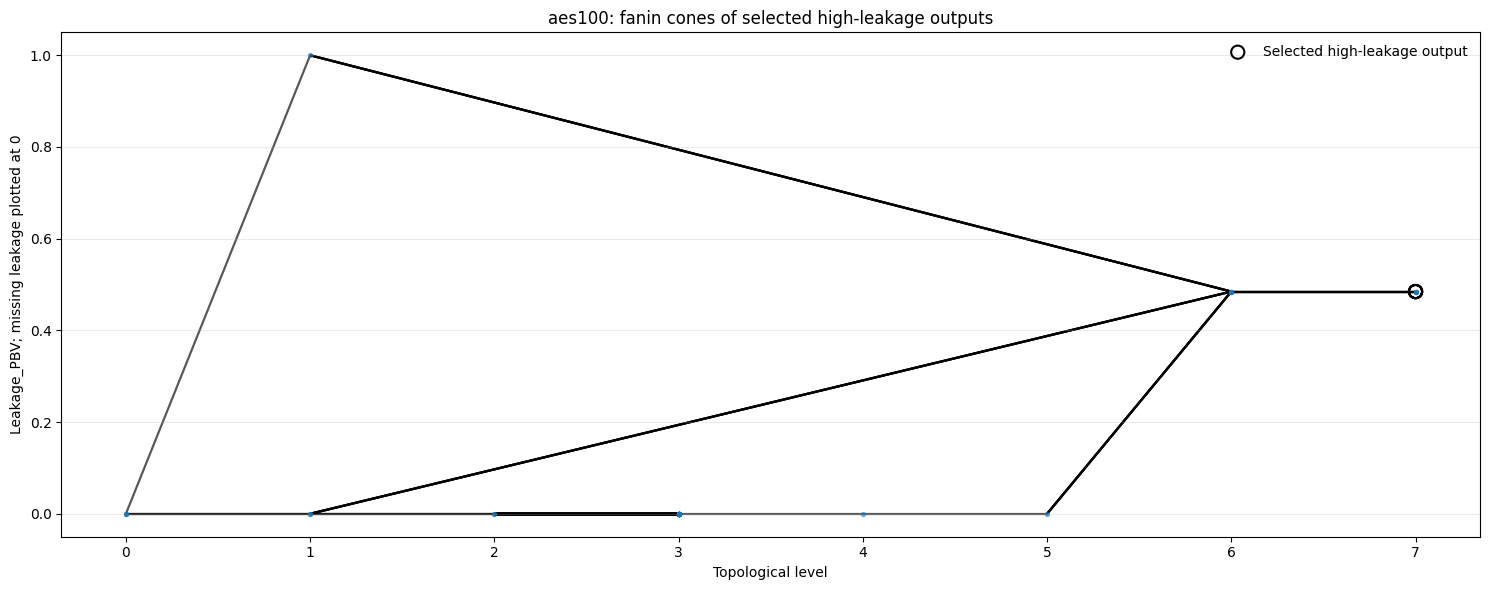

aes100: fanin-only drawable_edges=111, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes100/aes100_fanin_only.png


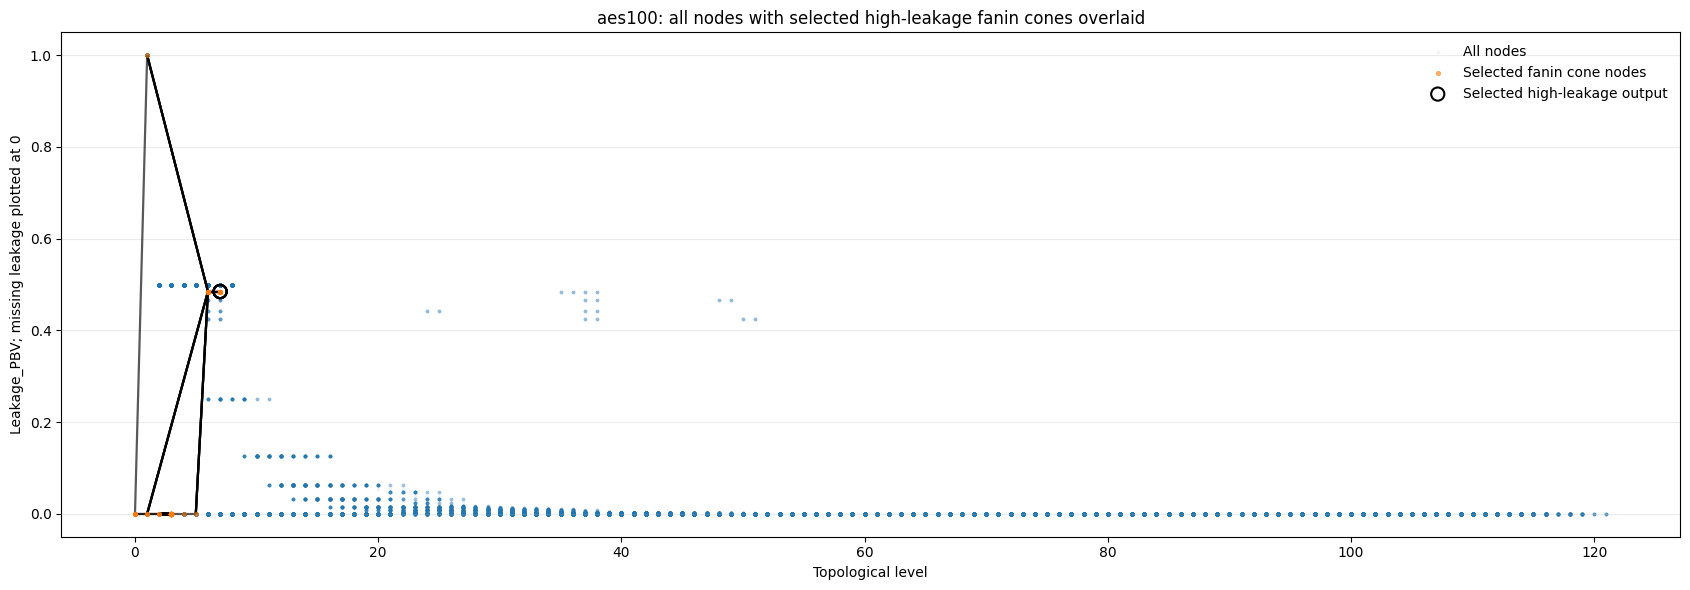

aes100: full-overlay drawable_edges=111, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes100/aes100_full_overlay.png


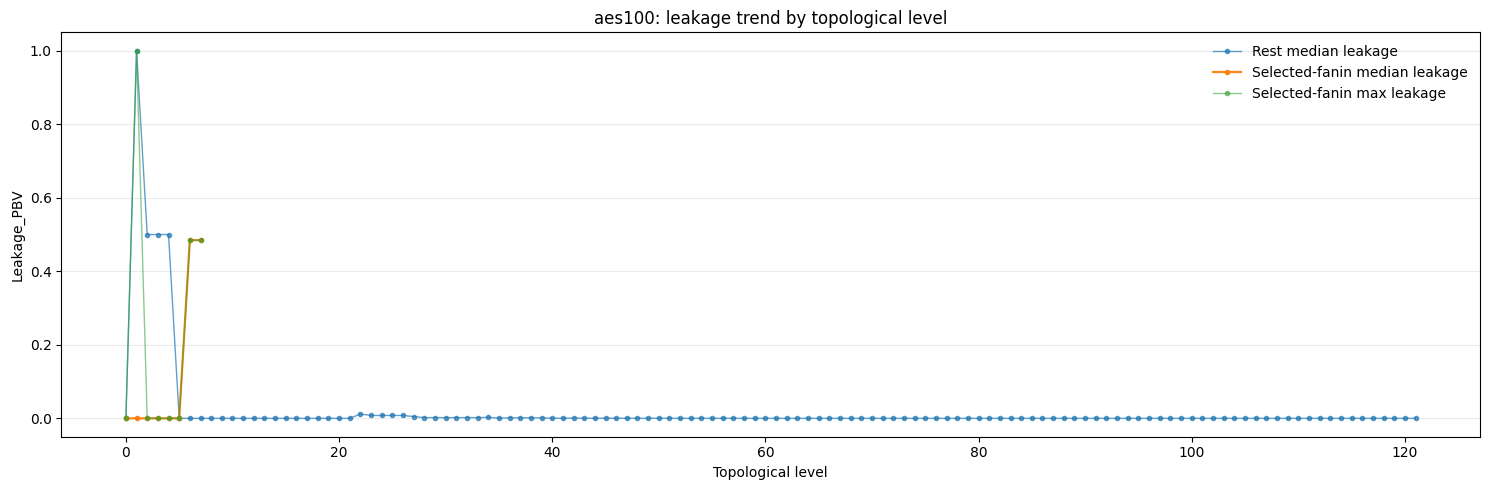

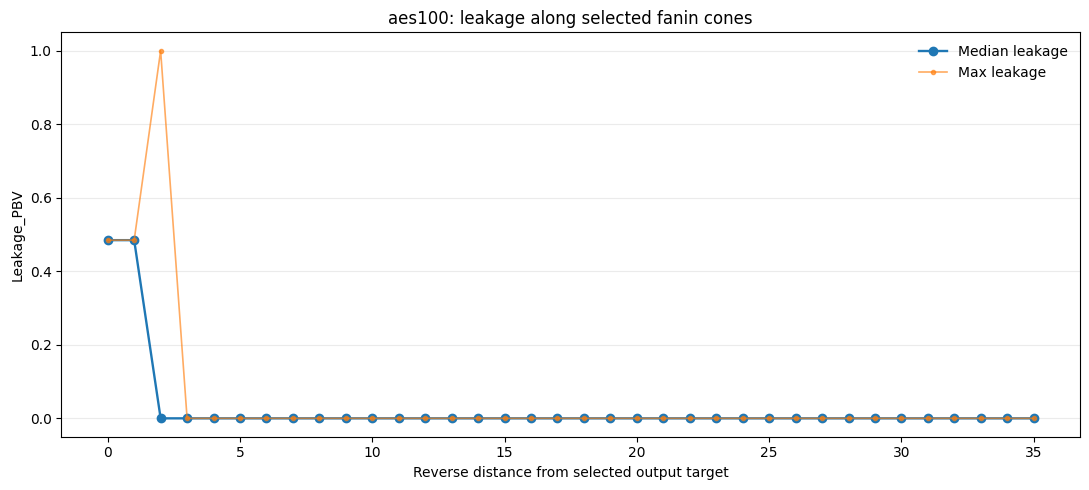

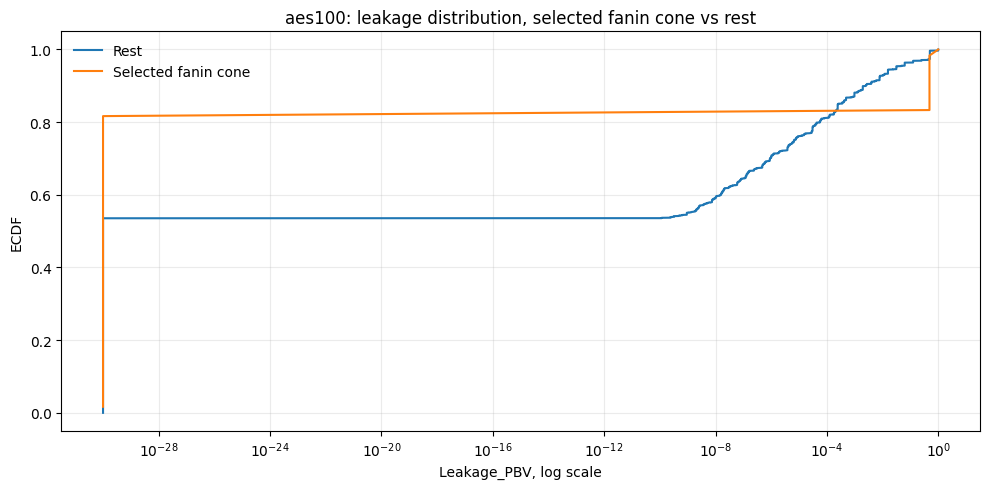

,design,node,topological_level,scc_size,indegree,outdegree,has_leakage,leakage,plot_leakage,best_ref,actual_signal,actual_ref,pbv,prior,leakage_percentile_global,leakage_percentile_same_level,leakage_log10,output_like_robust_z,is_selected_target,in_selected_fanin_cone,fanin_min_distance_to_target,fanin_targets_reached
9453,aes100,top.Capacitance[10:10],7,1,1,0,True,0.484691,0.484691,top.key[1:1],top.Capacitance[10:10]@20,top.key[1:1],0.742345,0.5,0.974003,0.940964,-0.314535,0.86615,True,True,0,1
9455,aes100,top.Capacitance[11:11],7,1,1,0,True,0.484691,0.484691,top.key[1:1],top.Capacitance[11:11]@20,top.key[1:1],0.742345,0.5,0.974003,0.940964,-0.314535,0.86615,True,True,0,1
9457,aes100,top.Capacitance[12:12],7,1,1,0,True,0.484691,0.484691,top.key[1:1],top.Capacitance[12:12]@20,top.key[1:1],0.742345,0.5,0.974003,0.940964,-0.314535,0.86615,True,True,0,1
9459,aes100,top.Capacitance[13:13],7,1,1,0,True,0.484691,0.484691,top.key[1:1],top.Capacitance[13:13]@20,top.key[1:1],0.742345,0.5,0.974003,0.940964,-0.314535,0.86615,True,True,0,1
9463,aes100,top.Capacitance[15:15],7,1,1,0,True,0.484691,0.484691,top.key[1:1],top.Capacitance[15:15]@20,top.key[1:1],0.742345,0.5,0.974003,0.940964,-0.314535,0.86615,True,True,0,1


,design,nodes,edges,is_raw_graph_dag,topological_levels,leakage_nodes,selected_targets,fanin_nodes,fanin_edges,fanin_leakage_nodes,rest_leakage_nodes,fanin_level_min,fanin_level_max,fanin_n,fanin_mean,fanin_std,fanin_min,fanin_p25,fanin_median,fanin_p75,fanin_p90,fanin_p95,fanin_p99,fanin_max,fanin_positive_log10_mean,rest_n,rest_mean,rest_std,rest_min,rest_p25,rest_median,rest_p75,rest_p90,rest_p95,rest_p99,rest_max,rest_positive_log10_mean,targets_n,targets_mean,targets_std,targets_min,targets_p25,targets_median,targets_p75,targets_p90,targets_p95,targets_p99,targets_max,targets_positive_log10_mean,auc_fanin_leakage_gt_rest,median_global_percentile_fanin,median_same_level_percentile_fanin,median_global_percentile_targets,median_same_level_percentile_targets,level_profile_mean_lift_cone_over_rest_median,level_profile_median_lift_cone_over_rest_median,level_profile_max_lift_cone_over_rest_median
0,aes100,80626,98310,False,122,76298,5,61,111,60,76238,0,7,60,0.097448,0.215232,0.0,0.0,0.0,0.0,0.484691,0.484691,0.695968,1.0,-0.285941,76238,0.018533,0.097671,0.0,0.0,0.0,0.000007,0.002513,0.03125,0.5,1.0,-4.817462,5,0.484691,0.0,0.484691,0.484691,0.484691,0.484691,0.484691,0.484691,0.484691,0.484691,-0.314535,0.397641,0.267864,0.131503,0.974003,0.940964,0.318954,0.5,0.484691


In [28]:
# -----------------------------
# Run one design first while tuning parameters
# -----------------------------
# Change the index to test another design.

one_bundle = analyze_design(DESIGN_SPECS[0], design_index=0)
display(one_bundle["target_df"].head(30))
display(pd.DataFrame([one_bundle["stats"]]))



=== aes100 ===
parents: fortify/results/aes/aes100_recon/parents.txt
leakage: fortify/results/aes/aes100_recon/all_signal_leakage.csv
nodes=80626, edges=98310, DAG=False
topological levels=122
leakage nodes=76298
selected targets=5, cone_nodes=61, cone_edges=111

Distribution summary:
  leakage nodes: 76298
  selected targets: 5
  fanin leakage nodes: 60
  rest leakage nodes: 76238
  fanin median leakage: 0.000000e+00
  rest median leakage:  0.000000e+00
  fanin p90 leakage:    4.846909e-01
  rest p90 leakage:     2.512604e-03
  AUC P(fanin leakage > rest leakage): 0.3976
  median same-level percentile of fanin nodes: 0.1315
  median same-level percentile of targets:     0.9410


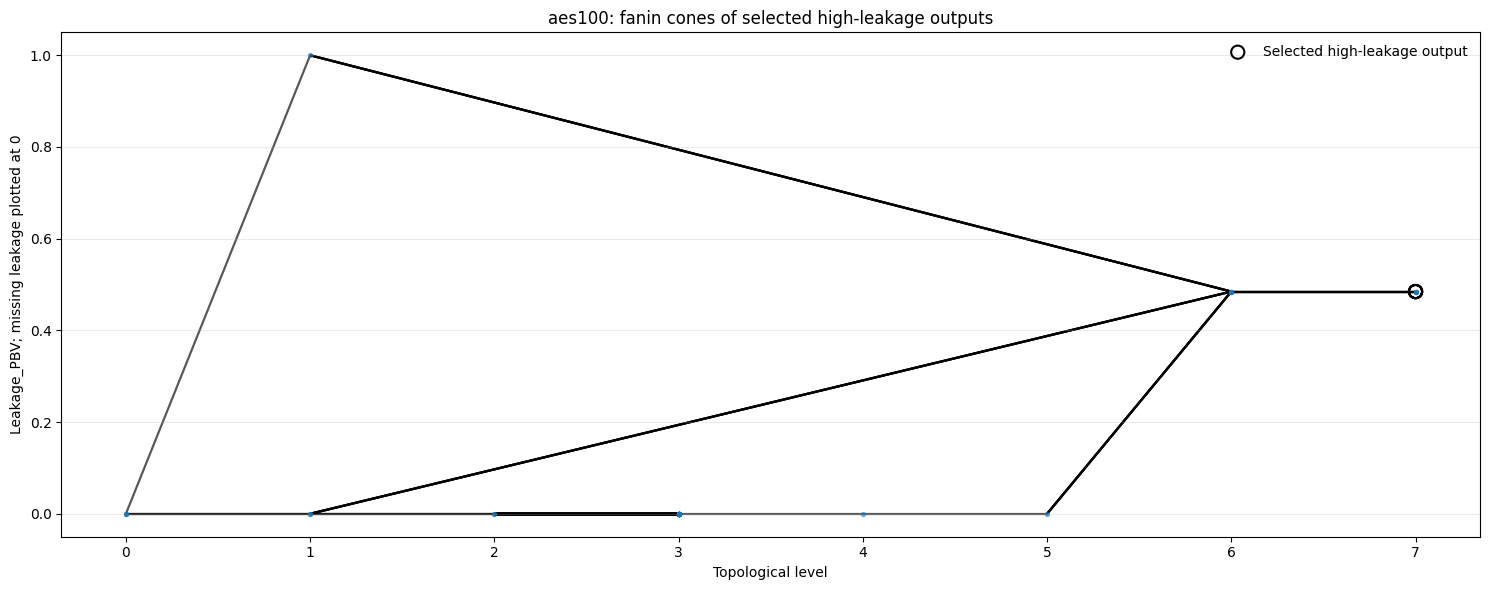

aes100: fanin-only drawable_edges=111, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes100/aes100_fanin_only.png


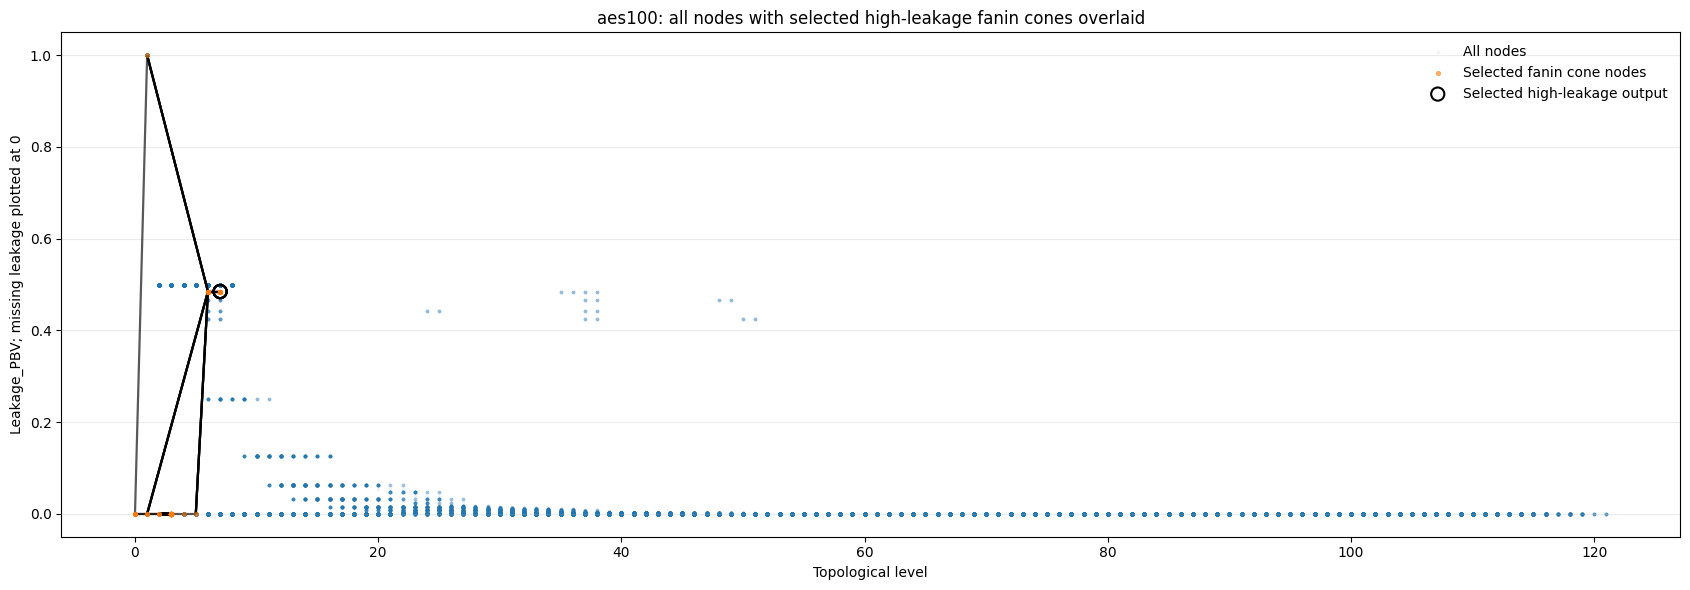

aes100: full-overlay drawable_edges=111, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes100/aes100_full_overlay.png


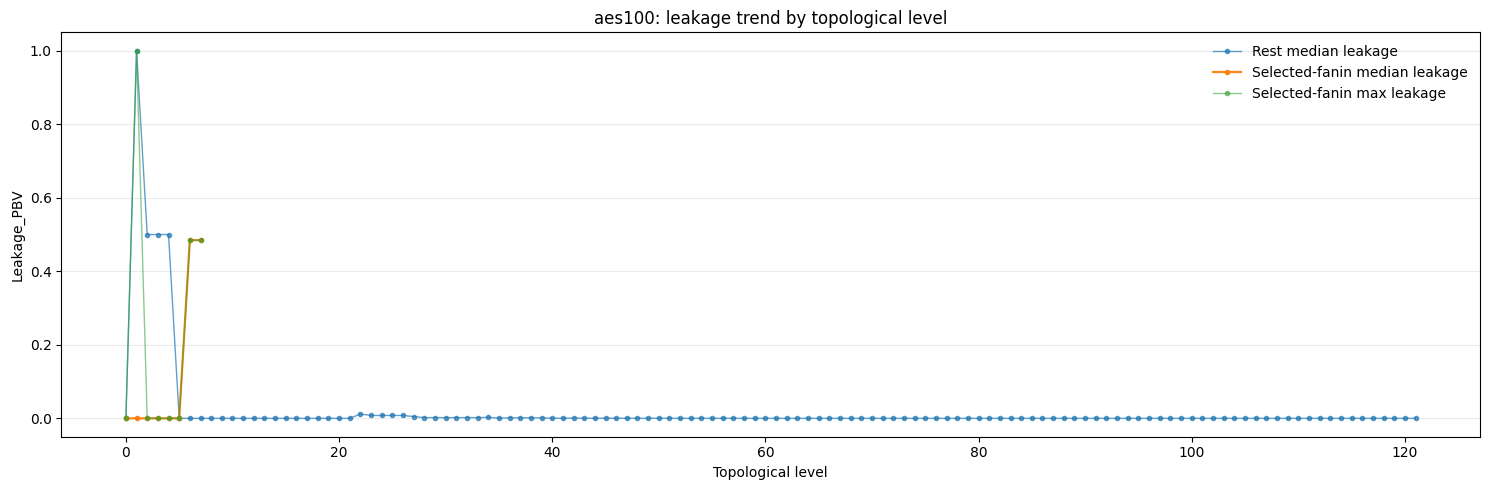

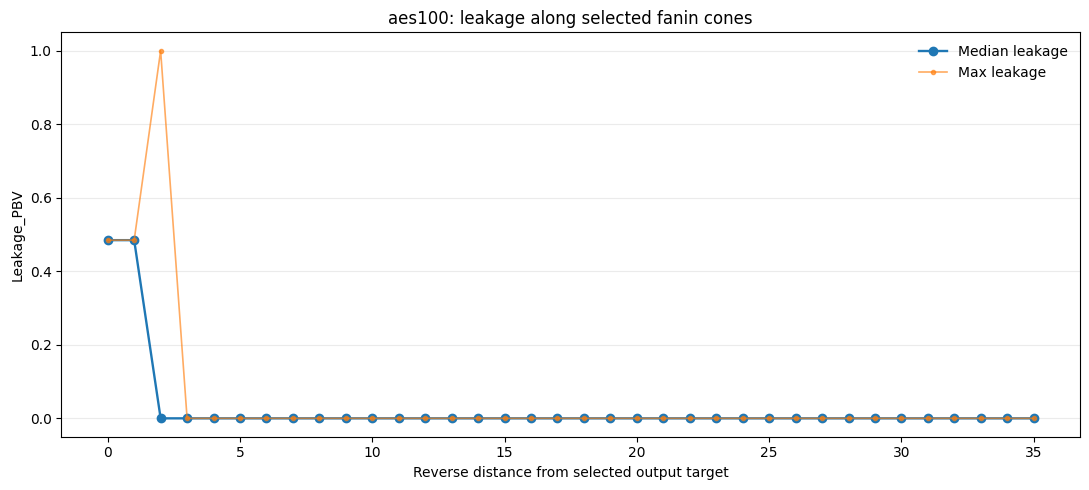

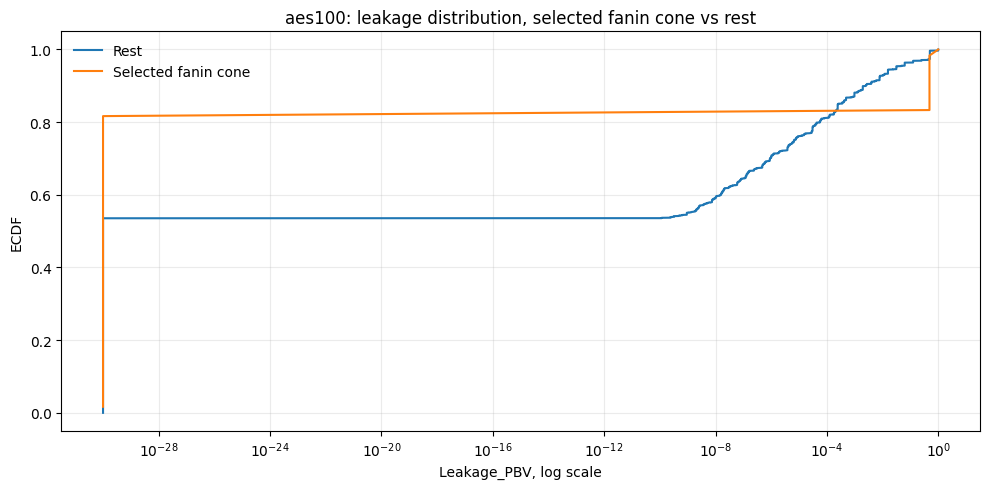


=== aes200 ===
parents: fortify/results/aes/aes200_recon/parents.txt
leakage: fortify/results/aes/aes200_recon/all_signal_leakage.csv
nodes=78942, edges=93958, DAG=True
topological levels=130
leakage nodes=78814
selected targets=5, cone_nodes=83, cone_edges=110

Distribution summary:
  leakage nodes: 78814
  selected targets: 5
  fanin leakage nodes: 81
  rest leakage nodes: 78733
  fanin median leakage: 0.000000e+00
  rest median leakage:  0.000000e+00
  fanin p90 leakage:    2.000000e-01
  rest p90 leakage:     1.953125e-03
  AUC P(fanin leakage > rest leakage): 0.3714
  median same-level percentile of fanin nodes: 0.2857
  median same-level percentile of targets:     0.9184


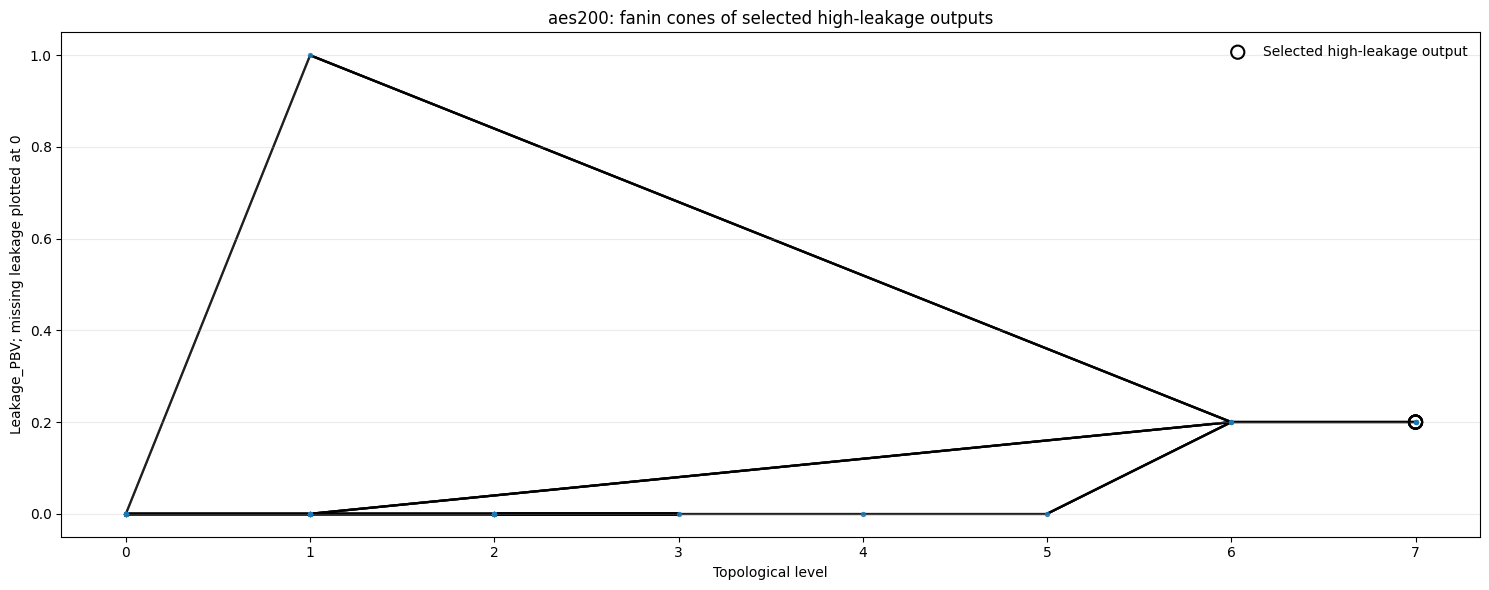

aes200: fanin-only drawable_edges=110, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes200/aes200_fanin_only.png


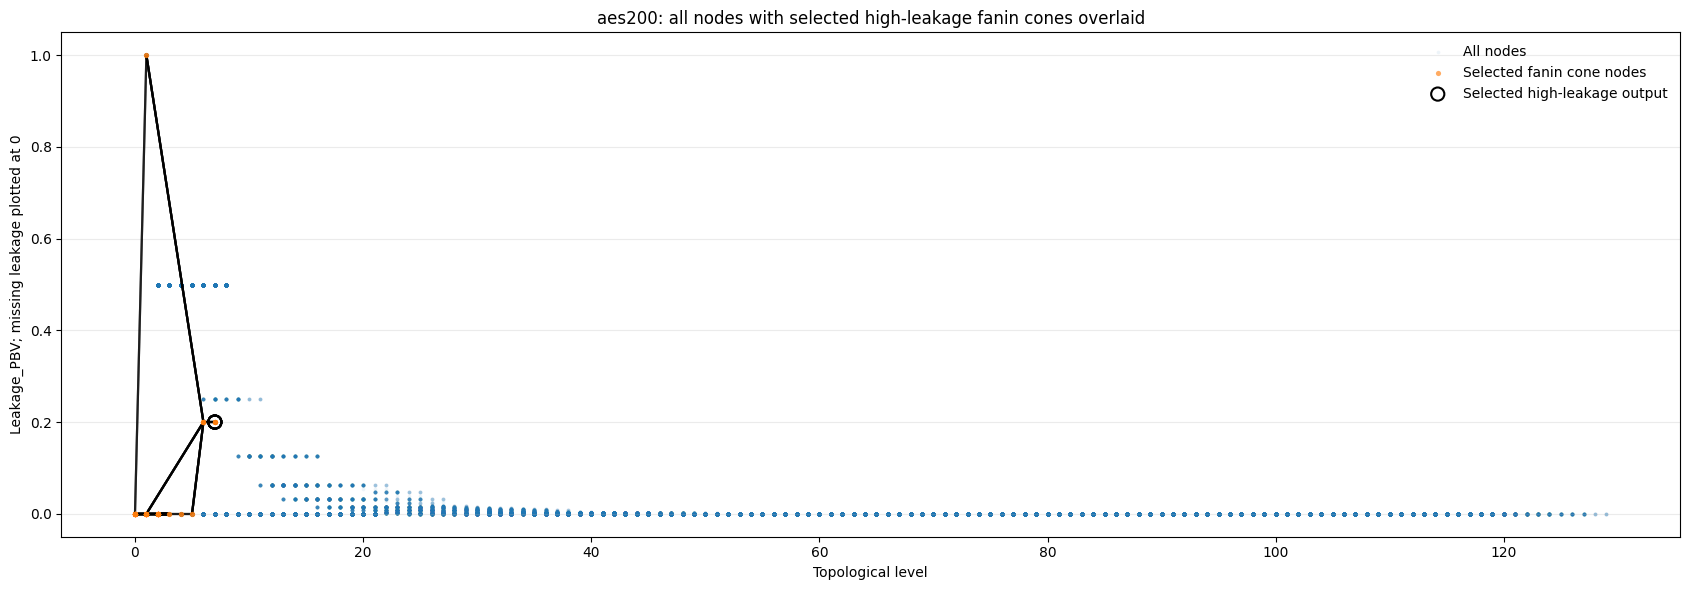

aes200: full-overlay drawable_edges=110, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes200/aes200_full_overlay.png


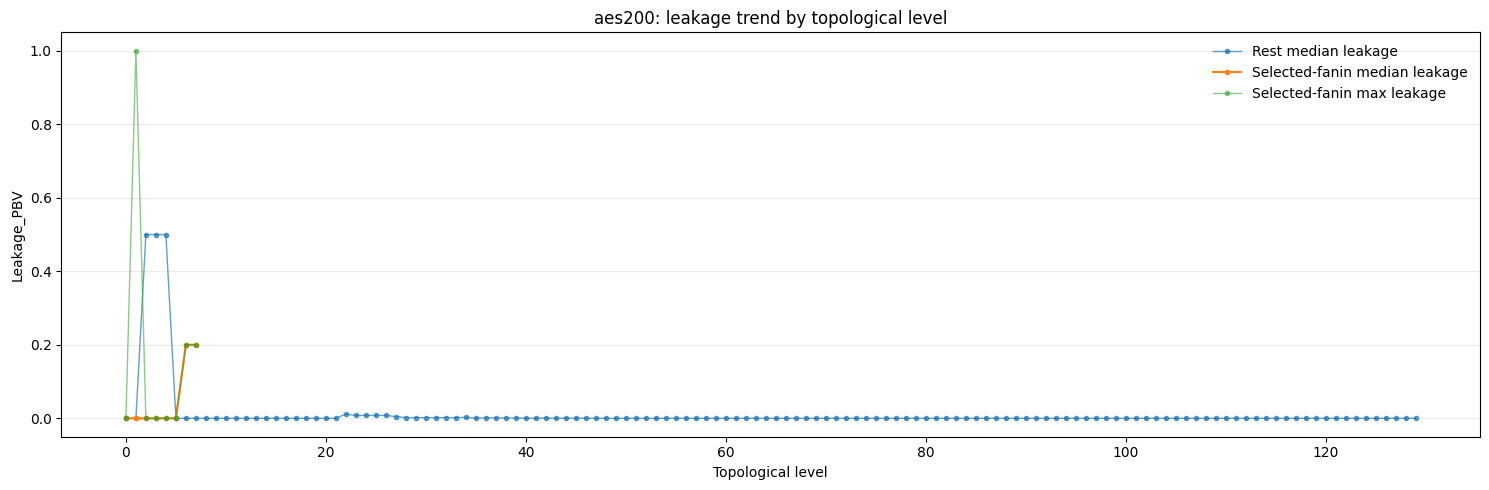

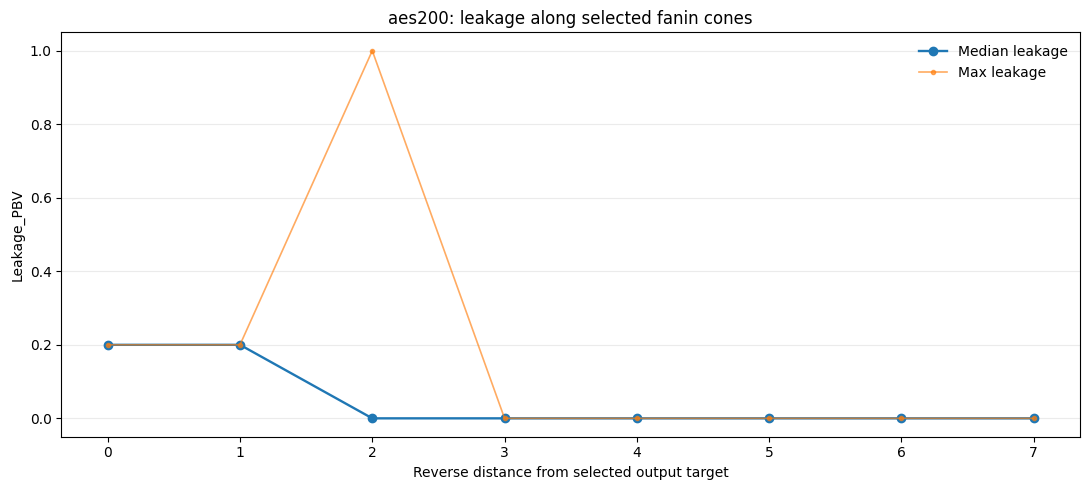

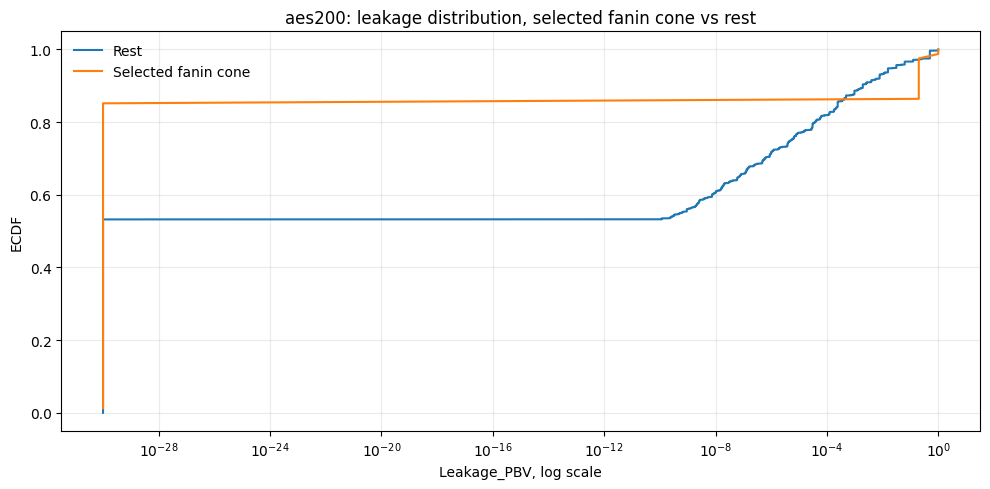


=== aes700 ===
parents: fortify/results/aes/aes700_recon/parents.txt
leakage: fortify/results/aes/aes700_recon/all_signal_leakage.csv
nodes=80760, edges=99303, DAG=False
topological levels=122
leakage nodes=76432
selected targets=5, cone_nodes=62, cone_edges=131

Distribution summary:
  leakage nodes: 76432
  selected targets: 5
  fanin leakage nodes: 61
  rest leakage nodes: 76371
  fanin median leakage: 0.000000e+00
  rest median leakage:  0.000000e+00
  fanin p90 leakage:    4.964026e-01
  rest p90 leakage:     2.512604e-03
  AUC P(fanin leakage > rest leakage): 0.3959
  median same-level percentile of fanin nodes: 0.1326
  median same-level percentile of targets:     0.9410


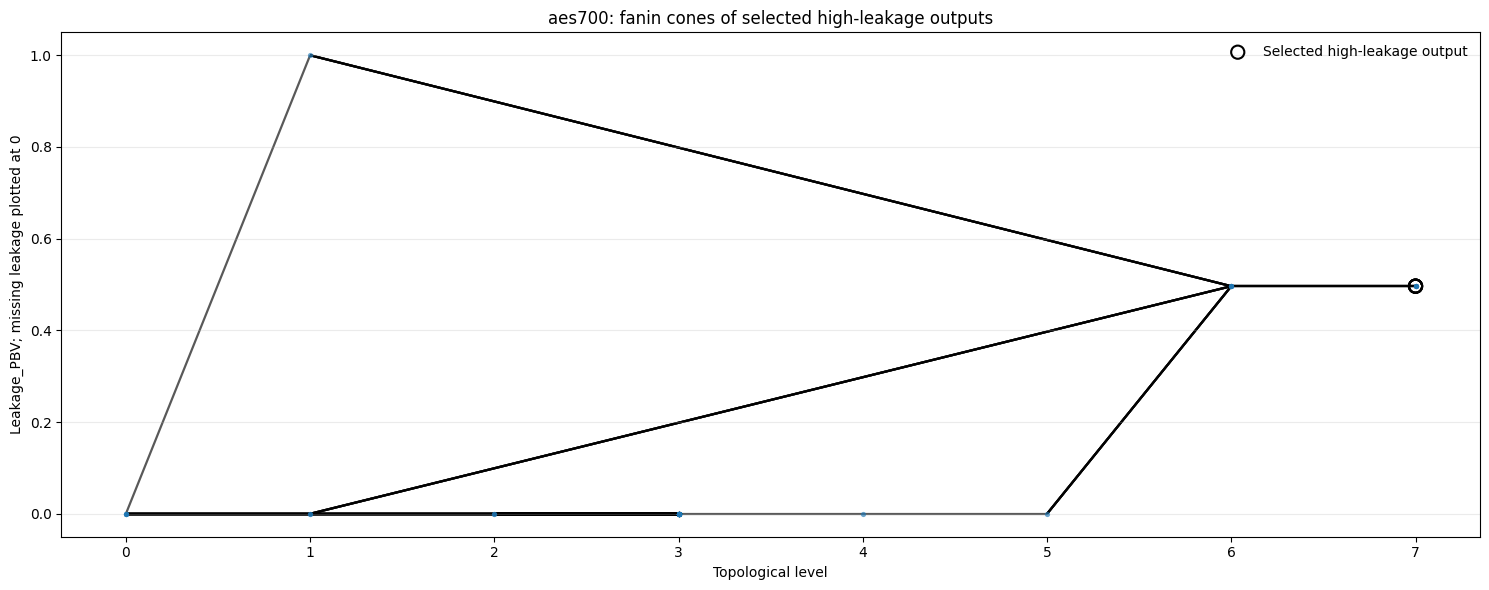

aes700: fanin-only drawable_edges=131, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes700/aes700_fanin_only.png


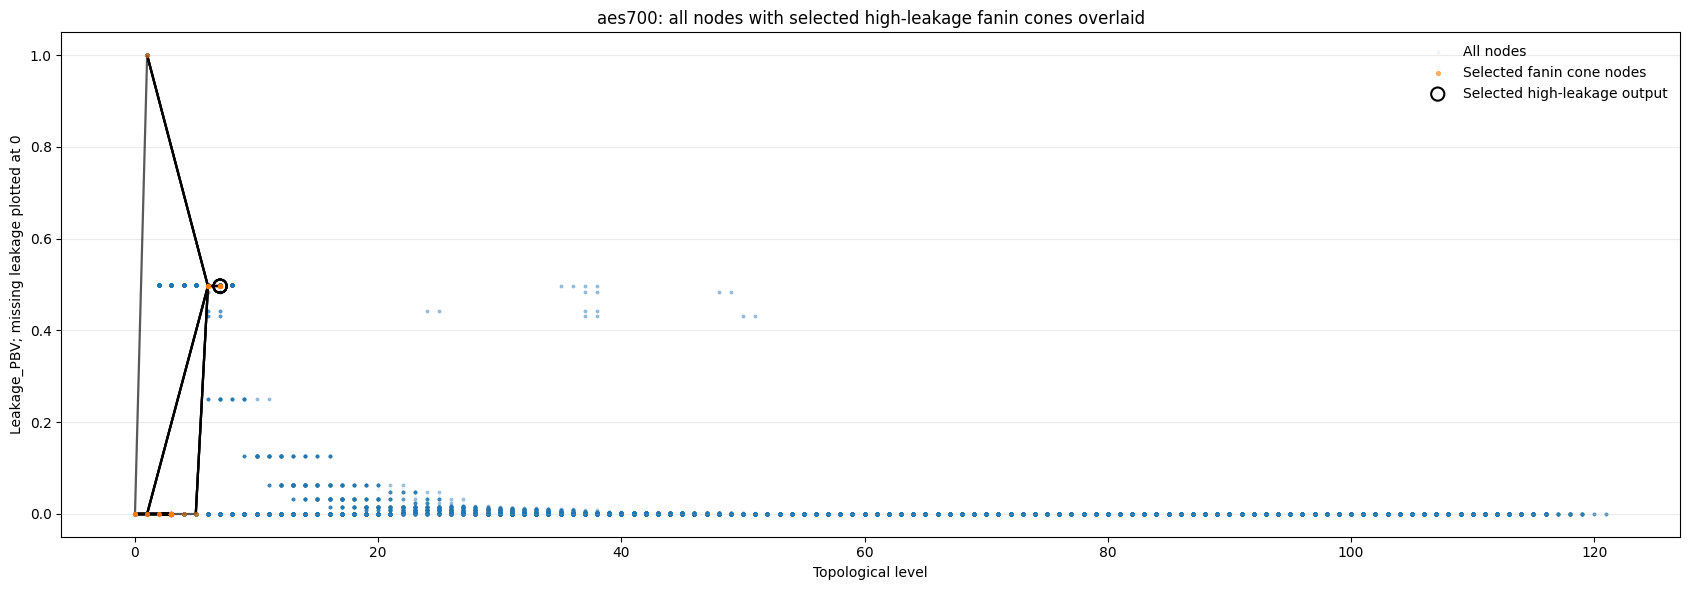

aes700: full-overlay drawable_edges=131, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes700/aes700_full_overlay.png


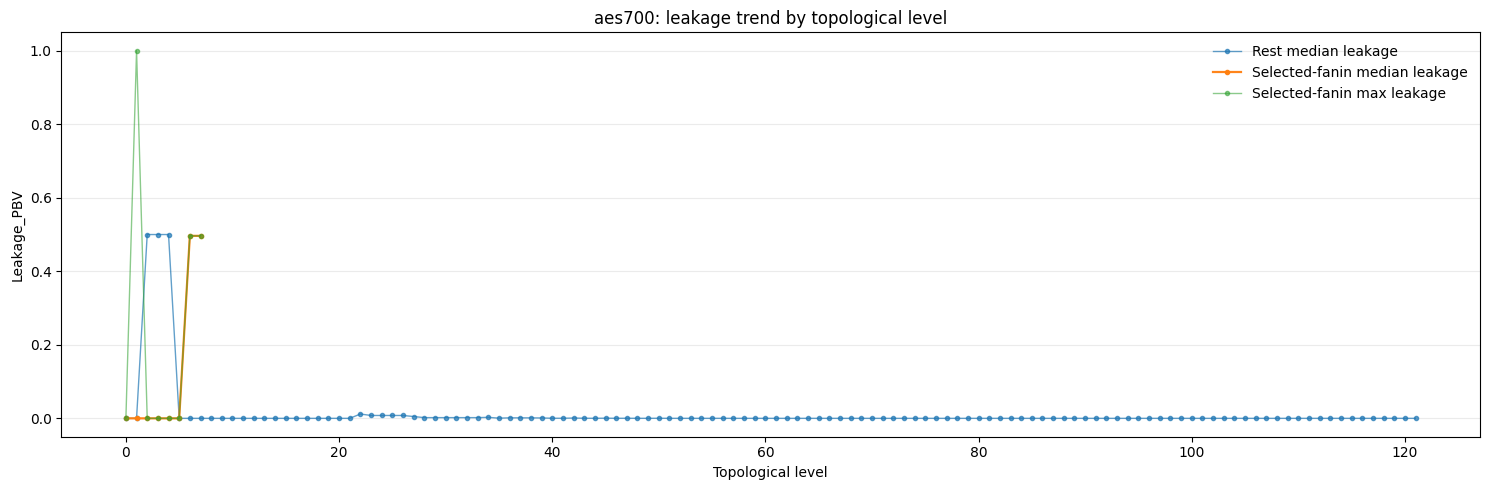

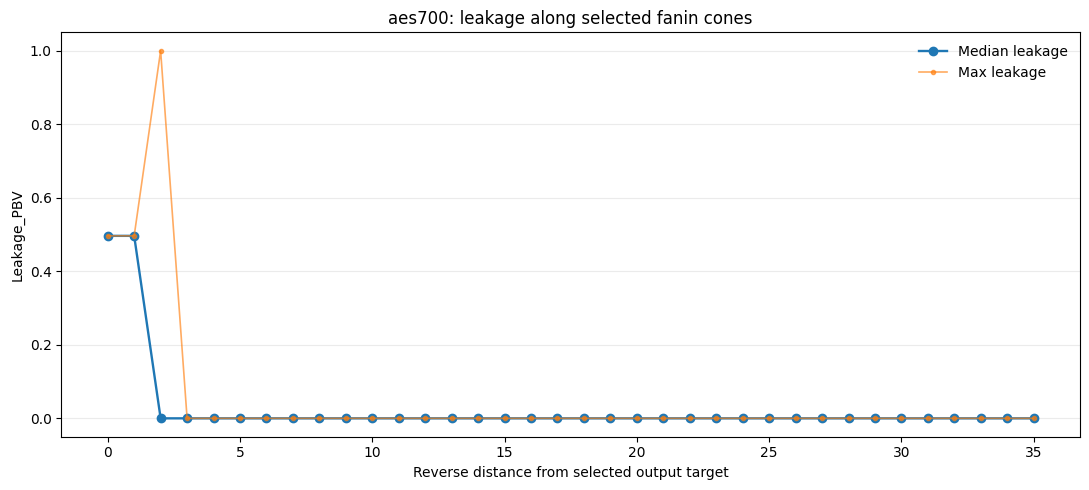

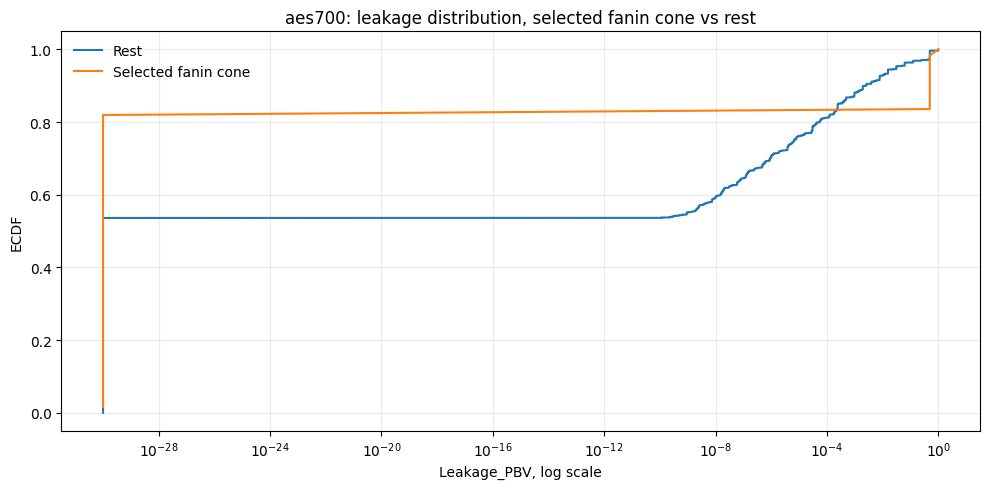


=== aes800 ===
parents: fortify/results/aes/aes800_recon/parents.txt
leakage: fortify/results/aes/aes800_recon/all_signal_leakage.csv
nodes=83253, edges=101792, DAG=False
topological levels=130
leakage nodes=78925
selected targets=5, cone_nodes=86, cone_edges=154

Distribution summary:
  leakage nodes: 78925
  selected targets: 5
  fanin leakage nodes: 84
  rest leakage nodes: 78841
  fanin median leakage: 0.000000e+00
  rest median leakage:  0.000000e+00
  fanin p90 leakage:    4.686520e-01
  rest p90 leakage:     5.889893e-03
  AUC P(fanin leakage > rest leakage): 0.3823
  median same-level percentile of fanin nodes: 0.3066
  median same-level percentile of targets:     0.9422


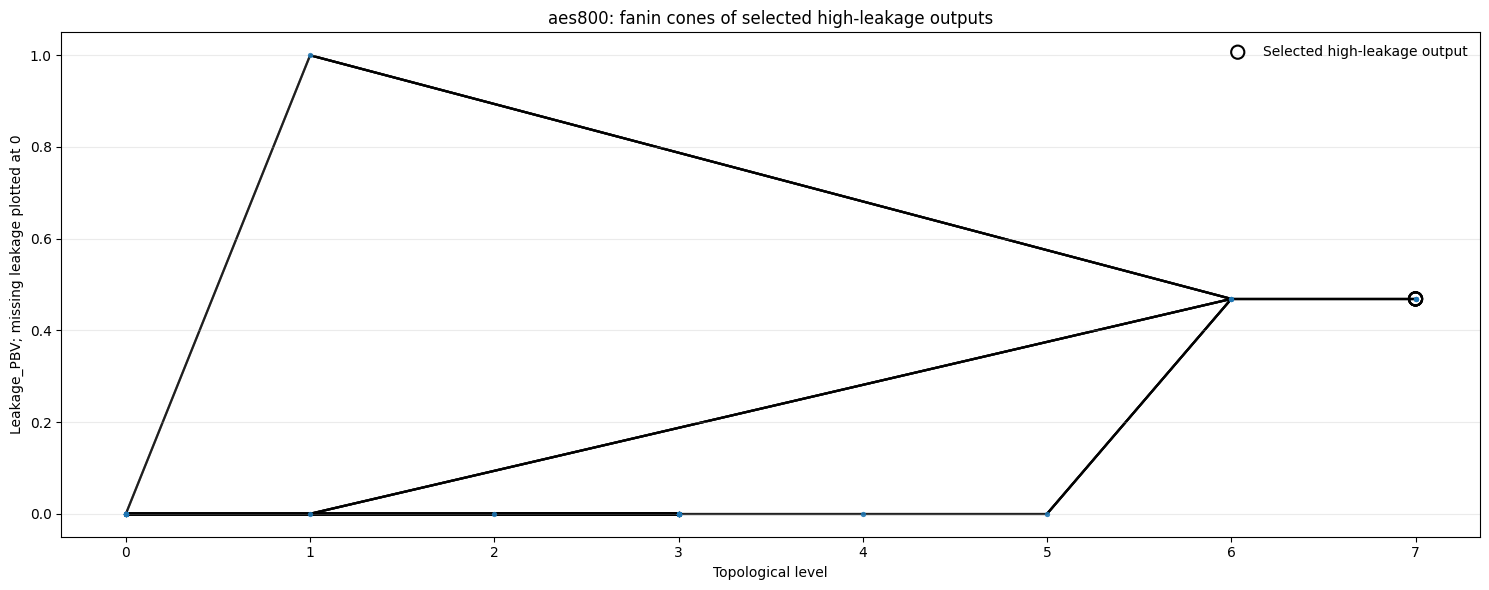

aes800: fanin-only drawable_edges=154, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes800/aes800_fanin_only.png


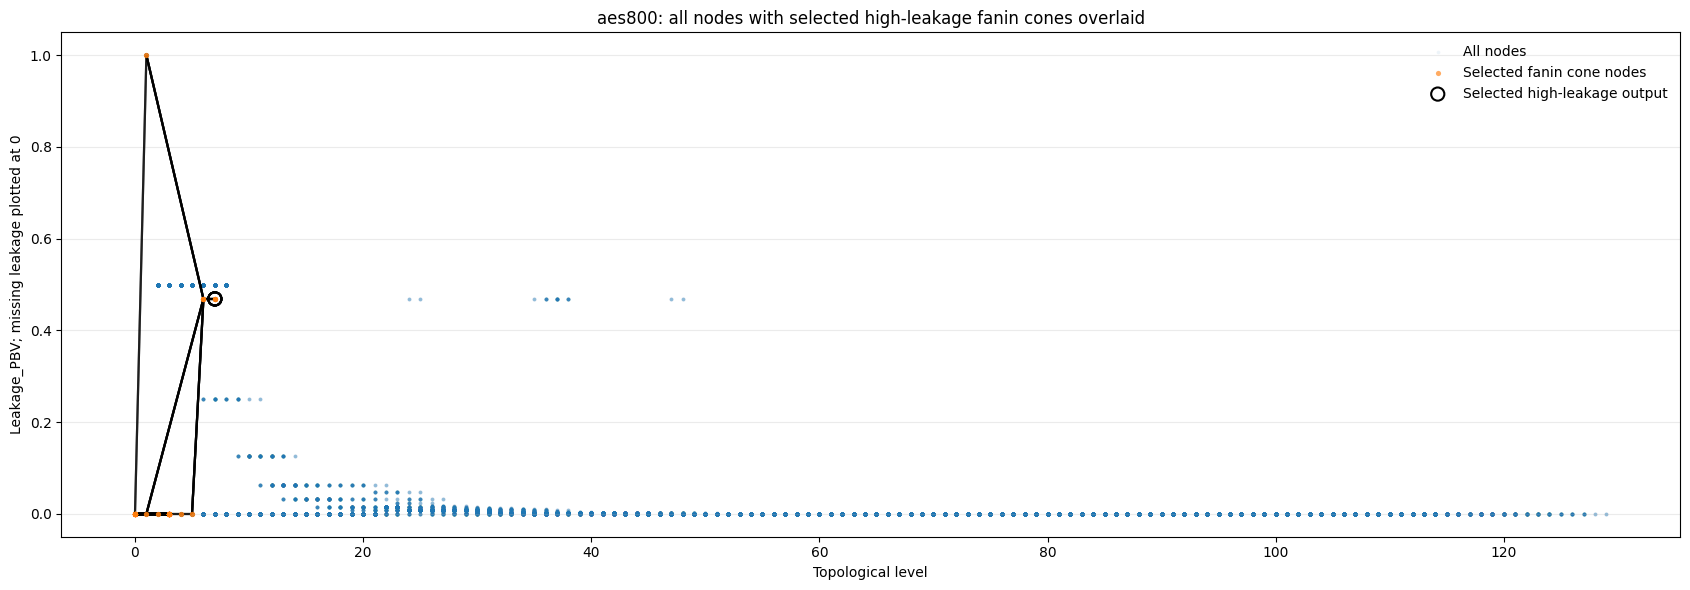

aes800: full-overlay drawable_edges=154, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes800/aes800_full_overlay.png


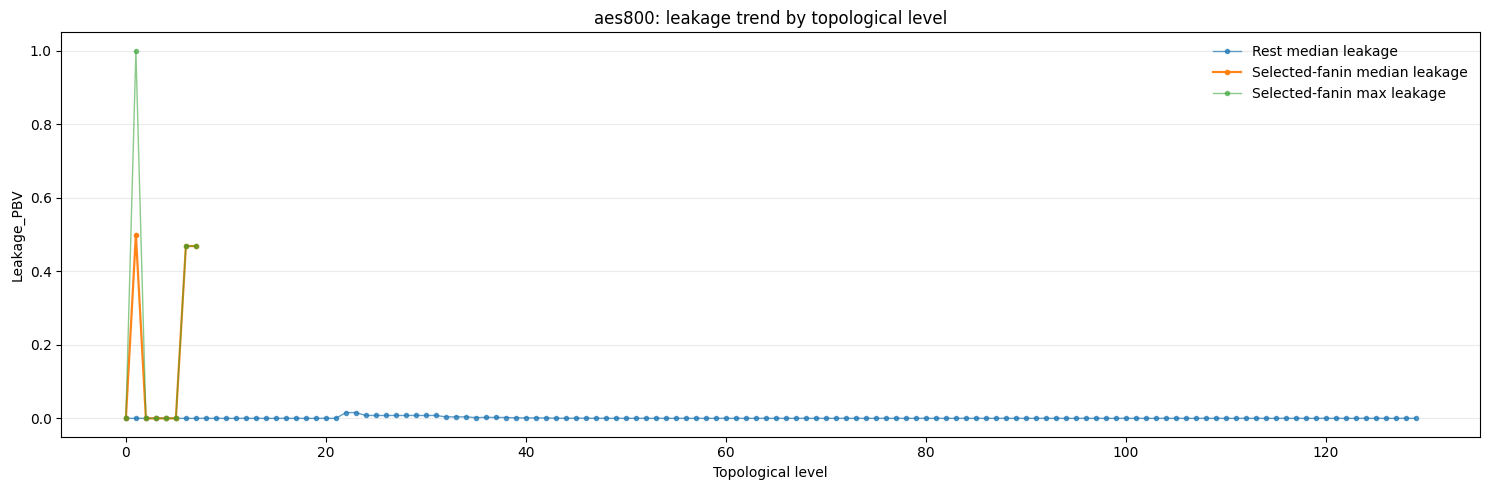

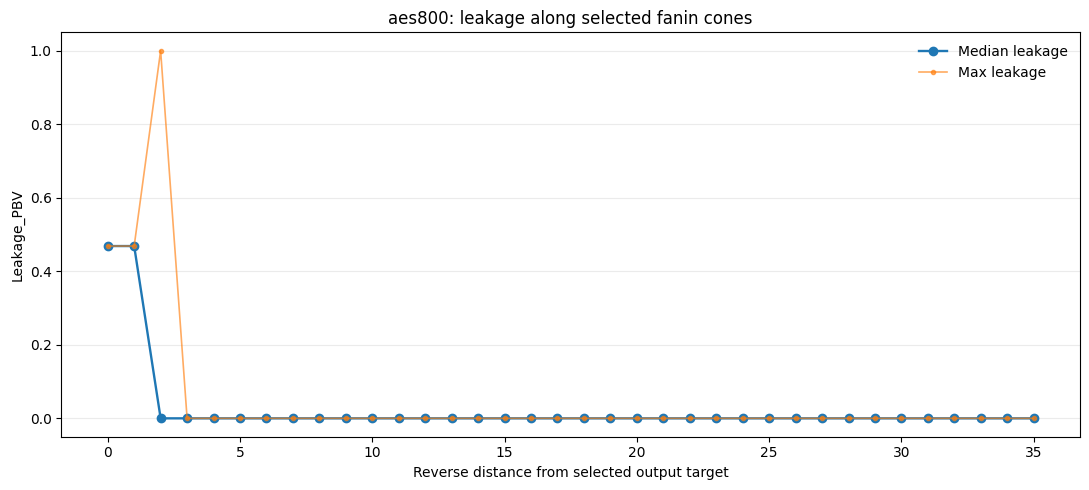

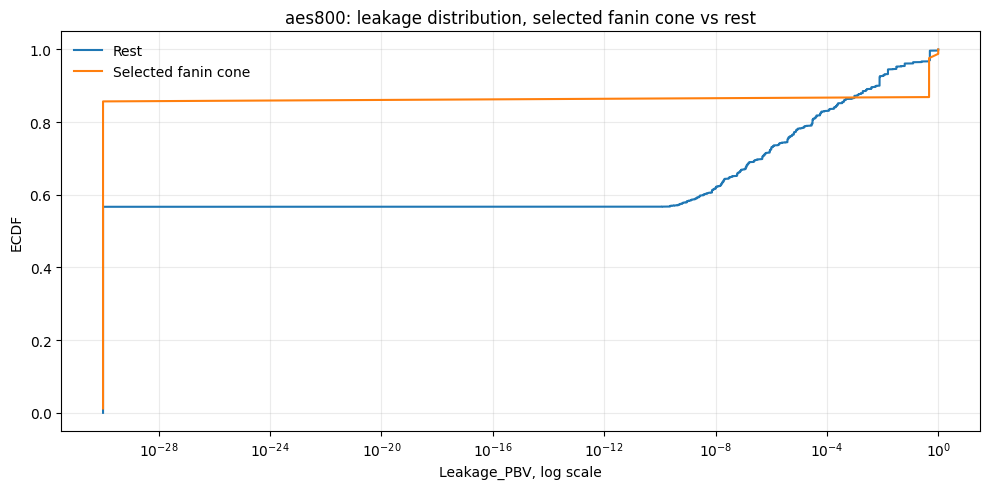


=== aes1100 ===
parents: fortify/results/aes/aes1100_recon/parents.txt
leakage: fortify/results/aes/aes1100_recon/all_signal_leakage.csv
nodes=83253, edges=102176, DAG=False
topological levels=130
leakage nodes=78925
selected targets=5, cone_nodes=86, cone_edges=154

Distribution summary:
  leakage nodes: 78925
  selected targets: 5
  fanin leakage nodes: 84
  rest leakage nodes: 78841
  fanin median leakage: 0.000000e+00
  rest median leakage:  0.000000e+00
  fanin p90 leakage:    4.686520e-01
  rest p90 leakage:     1.953125e-03
  AUC P(fanin leakage > rest leakage): 0.3675
  median same-level percentile of fanin nodes: 0.1368
  median same-level percentile of targets:     0.9422


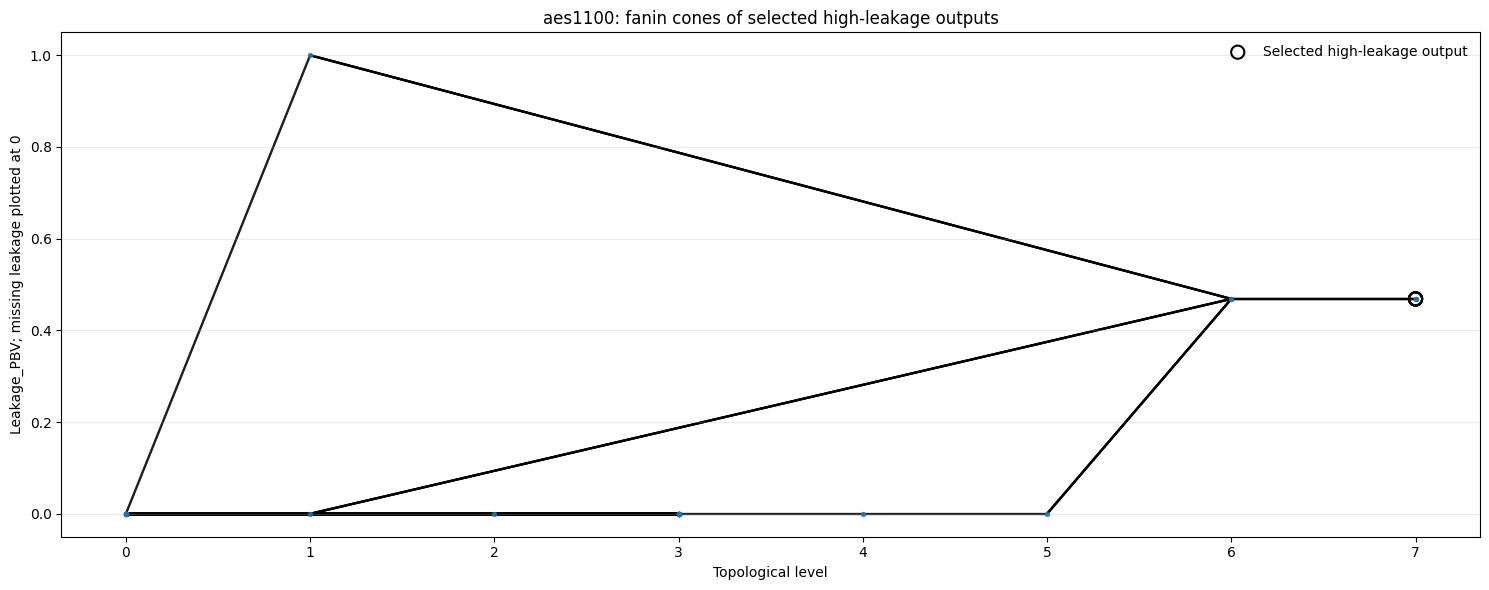

aes1100: fanin-only drawable_edges=154, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1100/aes1100_fanin_only.png


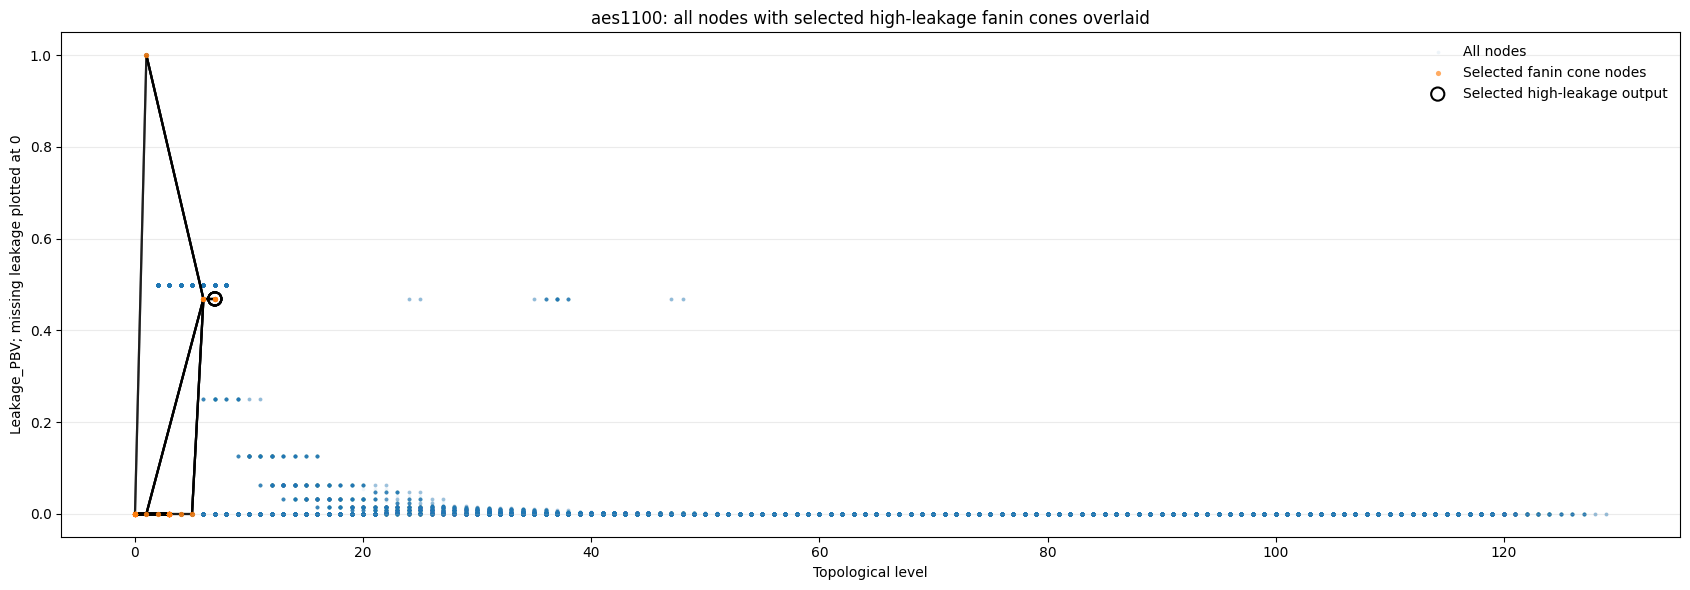

aes1100: full-overlay drawable_edges=154, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1100/aes1100_full_overlay.png


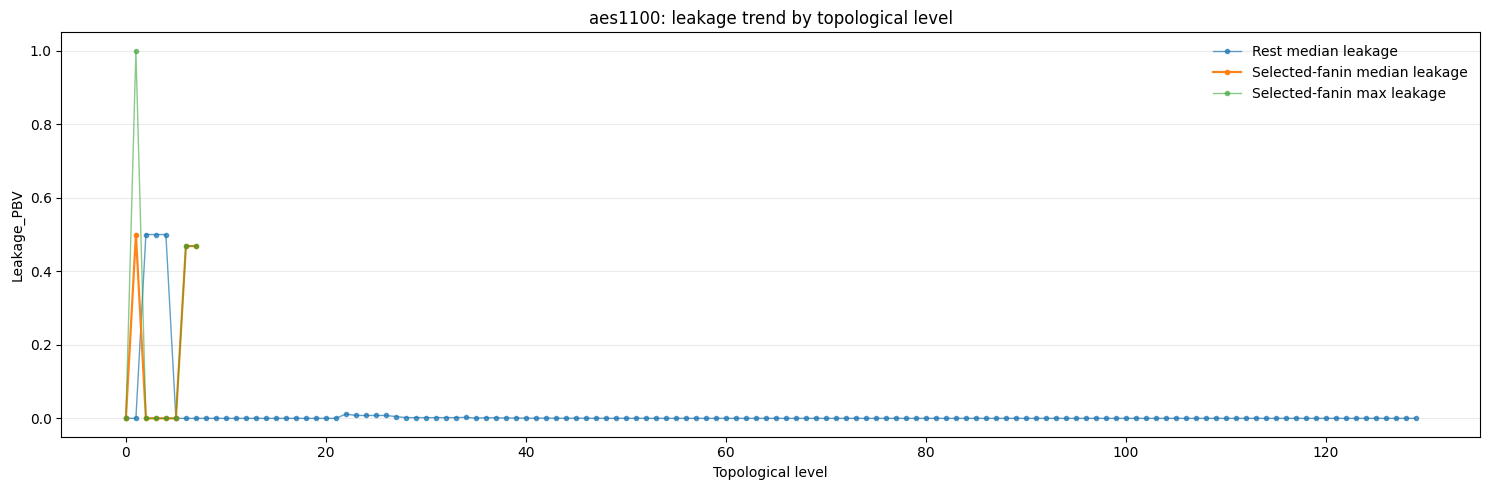

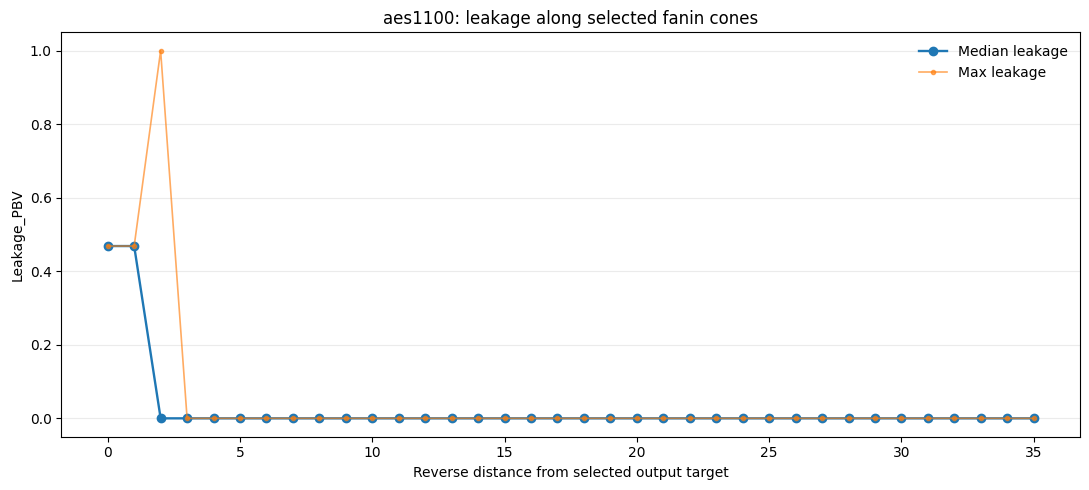

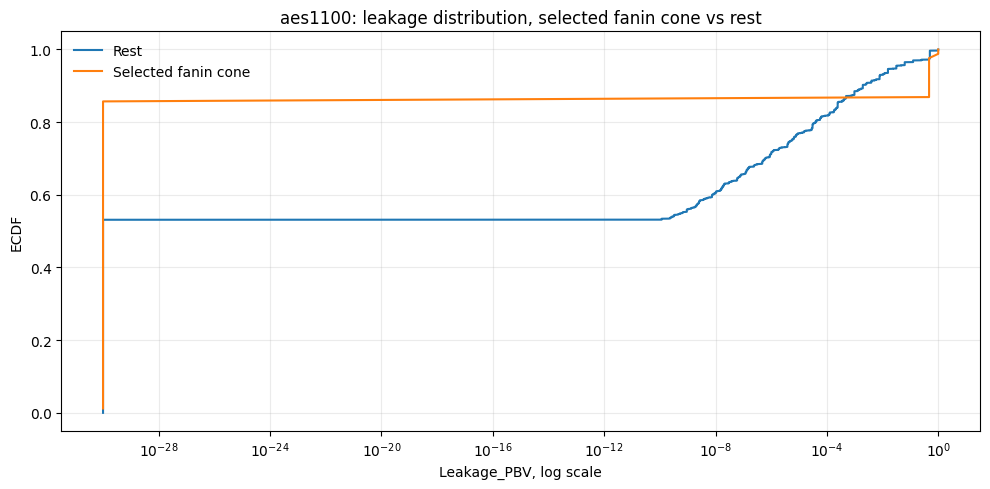


=== aes1200 ===
parents: fortify/results/aes/aes1200_recon/parents.txt
leakage: fortify/results/aes/aes1200_recon/all_signal_leakage.csv
nodes=120635, edges=181987, DAG=False
topological levels=471
leakage nodes=76580
selected targets=5, cone_nodes=82, cone_edges=151

Distribution summary:
  leakage nodes: 76580
  selected targets: 5
  fanin leakage nodes: 81
  rest leakage nodes: 76499
  fanin median leakage: 0.000000e+00
  rest median leakage:  0.000000e+00
  fanin p90 leakage:    4.686520e-01
  rest p90 leakage:     2.512604e-03
  AUC P(fanin leakage > rest leakage): 0.3647
  median same-level percentile of fanin nodes: 0.1336
  median same-level percentile of targets:     0.9410


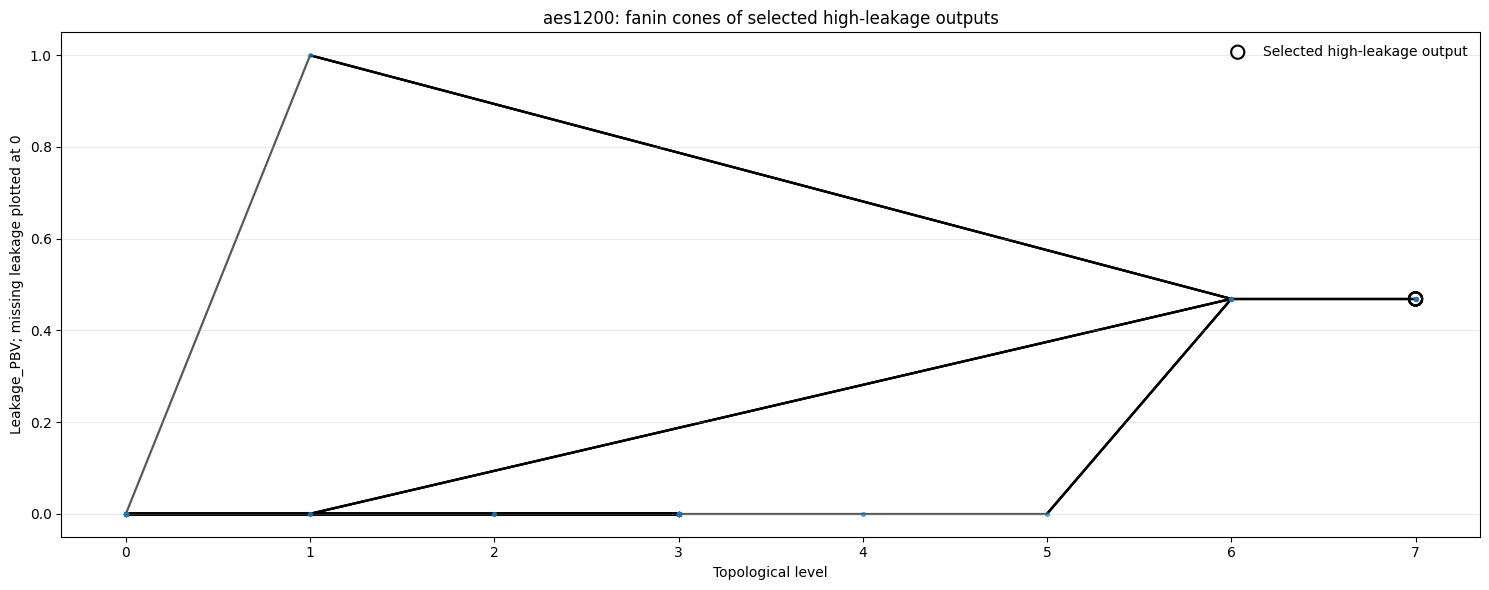

aes1200: fanin-only drawable_edges=151, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1200/aes1200_fanin_only.png


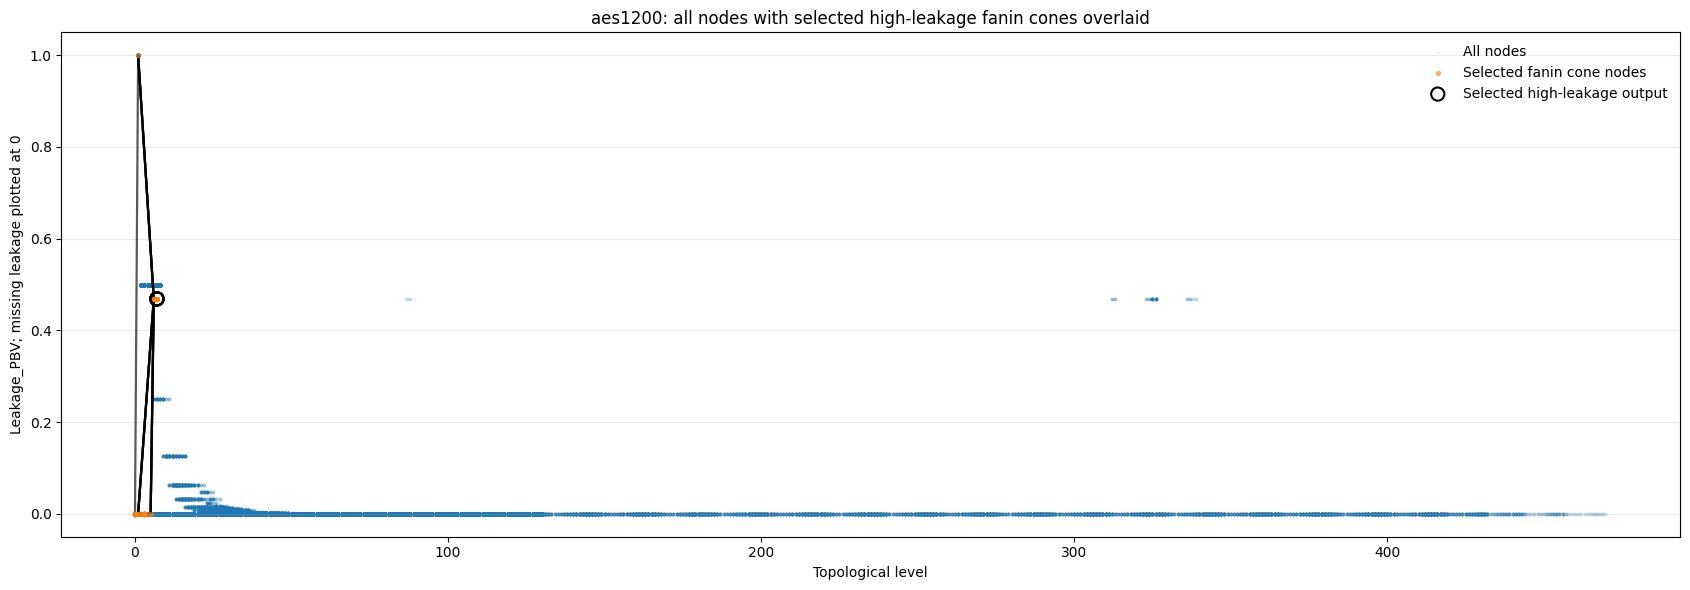

aes1200: full-overlay drawable_edges=151, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1200/aes1200_full_overlay.png


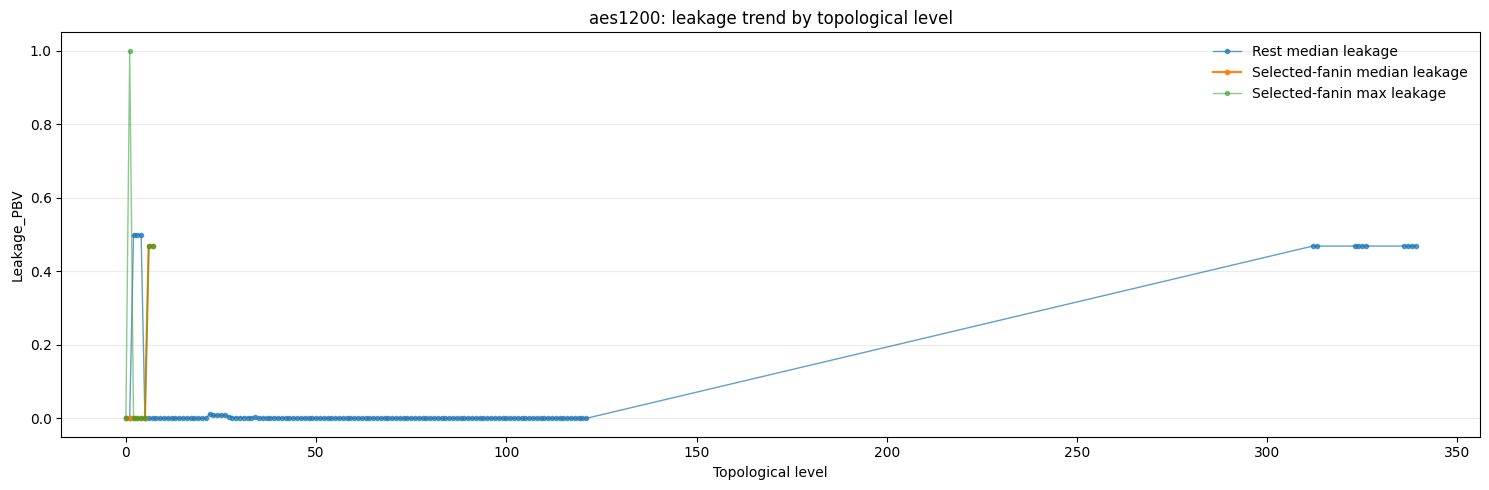

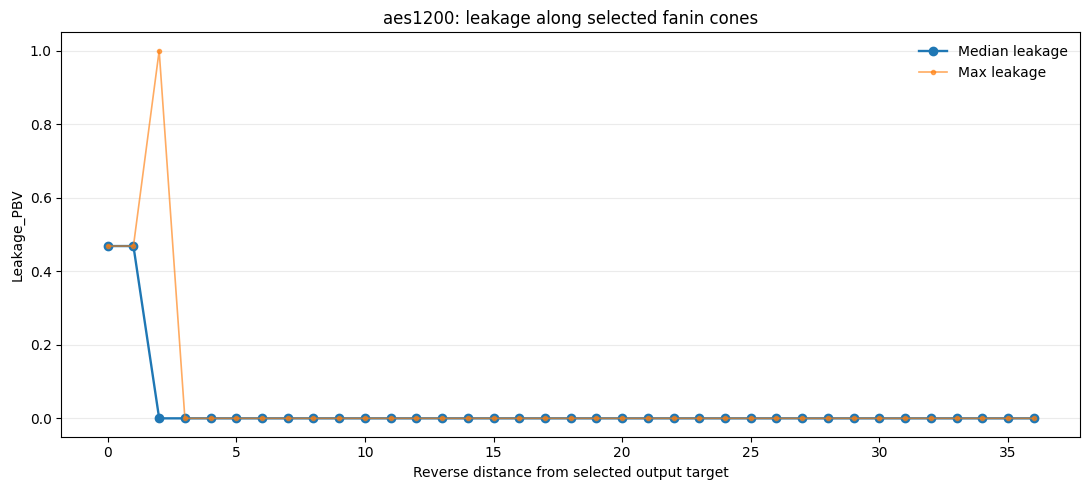

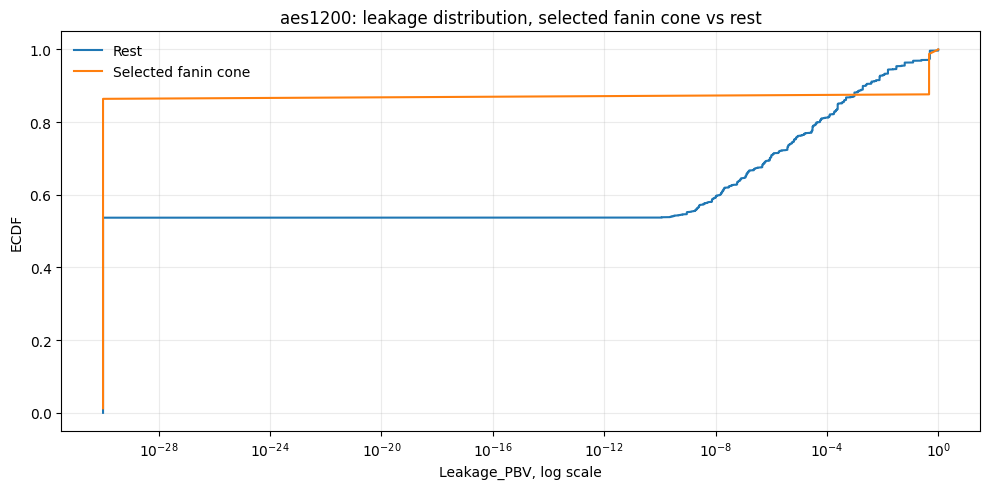


=== aes1600 ===
parents: fortify/results/aes/aes1600_recon/parents.txt
leakage: fortify/results/aes/aes1600_recon/all_signal_leakage.csv
nodes=83259, edges=536567, DAG=False
topological levels=130
leakage nodes=78686
selected targets=5, cone_nodes=2096, cone_edges=2664

Distribution summary:
  leakage nodes: 78686
  selected targets: 5
  fanin leakage nodes: 2081
  rest leakage nodes: 76605
  fanin median leakage: 3.878216e-06
  rest median leakage:  0.000000e+00
  fanin p90 leakage:    4.711914e-02
  rest p90 leakage:     1.949939e-03
  AUC P(fanin leakage > rest leakage): 0.6945
  median same-level percentile of fanin nodes: 0.5639
  median same-level percentile of targets:     0.3203


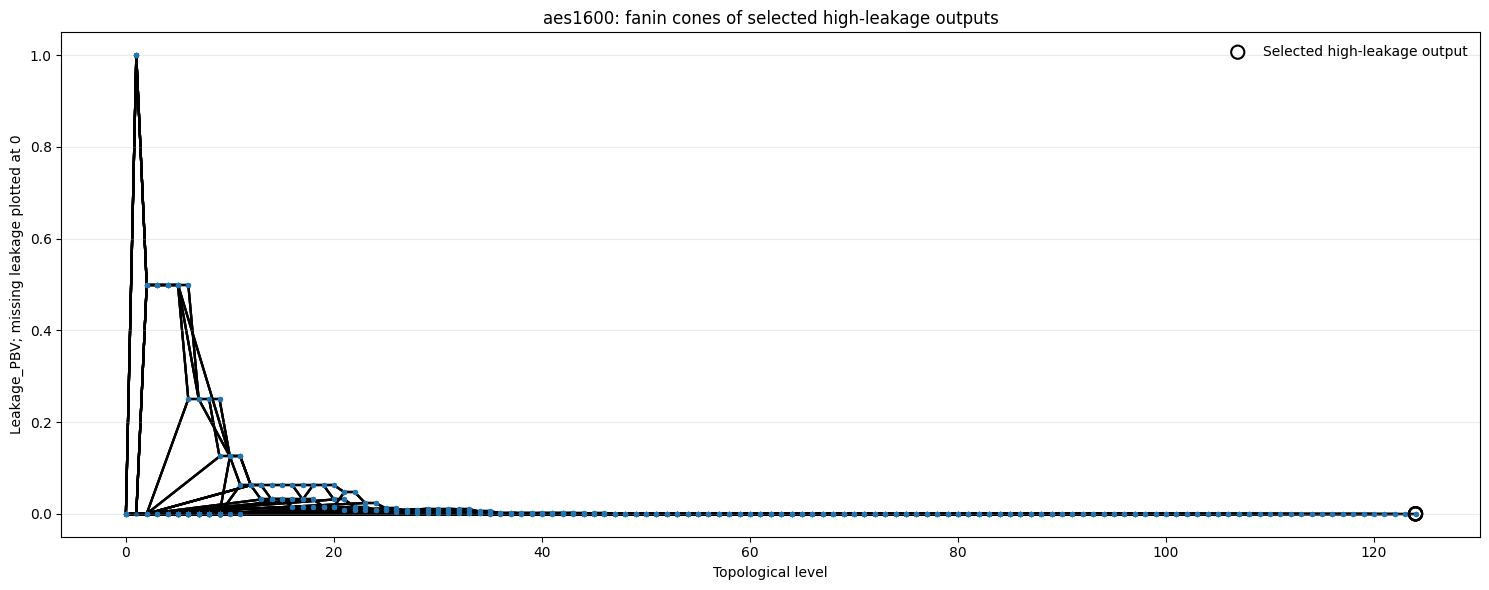

aes1600: fanin-only drawable_edges=2664, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1600/aes1600_fanin_only.png


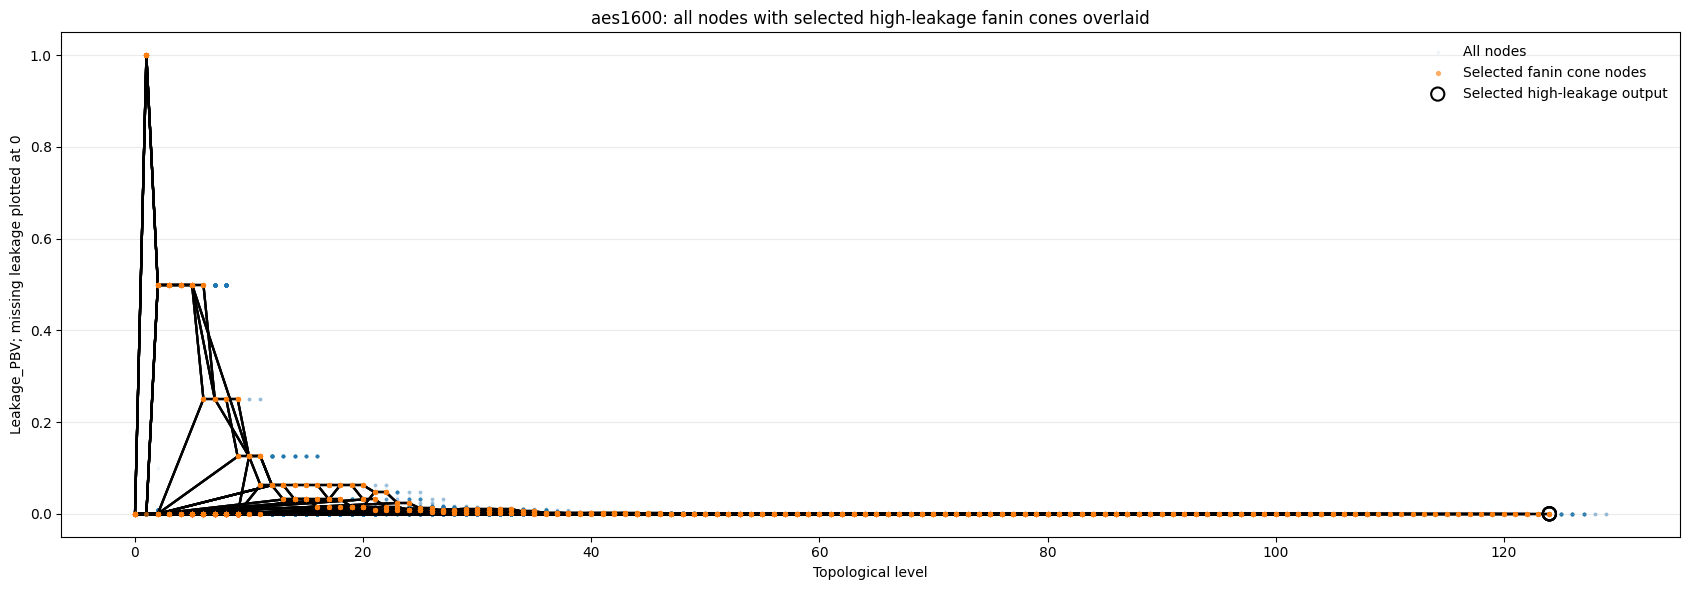

aes1600: full-overlay drawable_edges=2664, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1600/aes1600_full_overlay.png


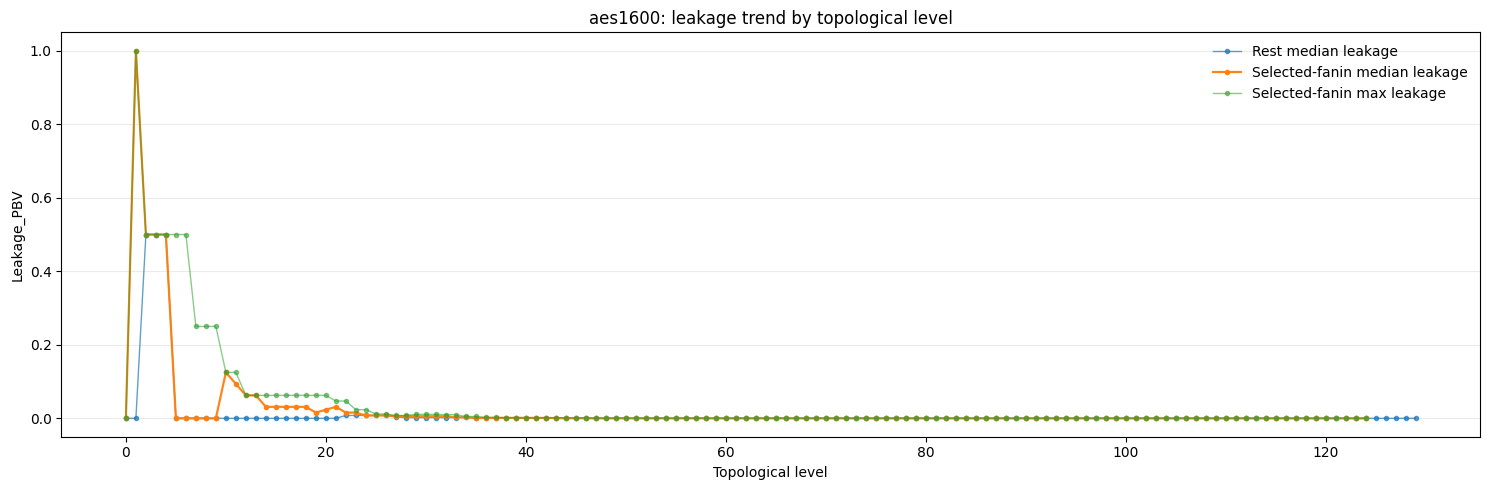

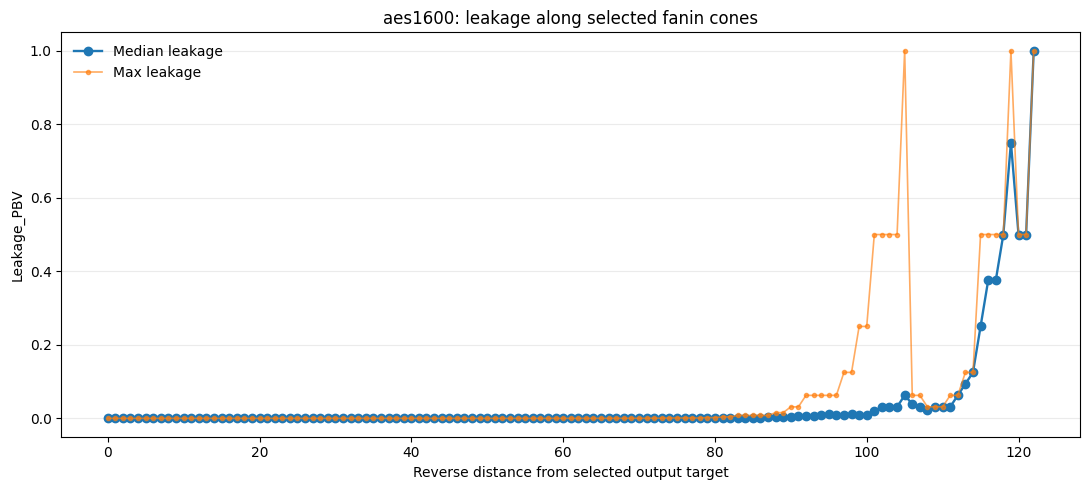

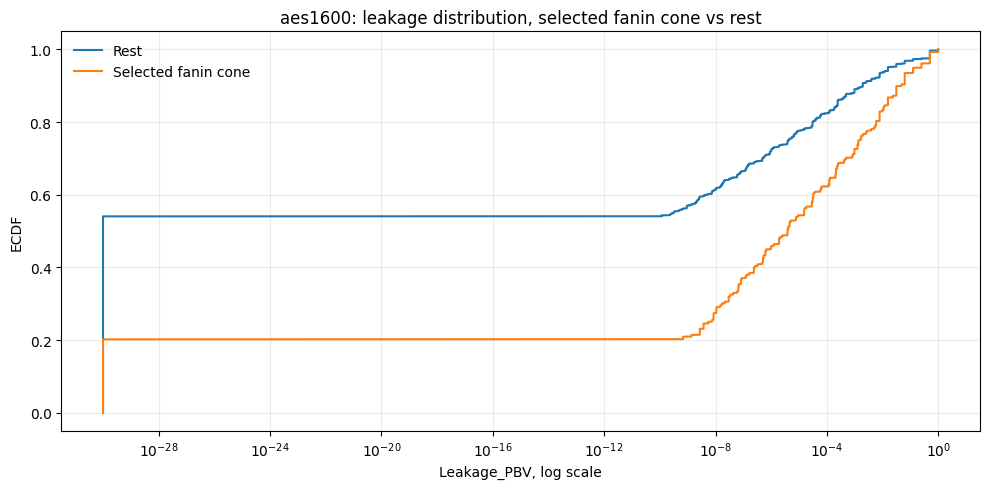


=== aes1700 ===
parents: fortify/results/aes/aes1700_recon/parents.txt
leakage: fortify/results/aes/aes1700_recon/all_signal_leakage.csv
nodes=116718, edges=2246781, DAG=True
topological levels=135
leakage nodes=78773
selected targets=5, cone_nodes=2096, cone_edges=2664

Distribution summary:
  leakage nodes: 78773
  selected targets: 5
  fanin leakage nodes: 2081
  rest leakage nodes: 76692
  fanin median leakage: 3.878216e-06
  rest median leakage:  0.000000e+00
  fanin p90 leakage:    4.711914e-02
  rest p90 leakage:     1.949939e-03
  AUC P(fanin leakage > rest leakage): 0.6947
  median same-level percentile of fanin nodes: 0.5639
  median same-level percentile of targets:     0.3203


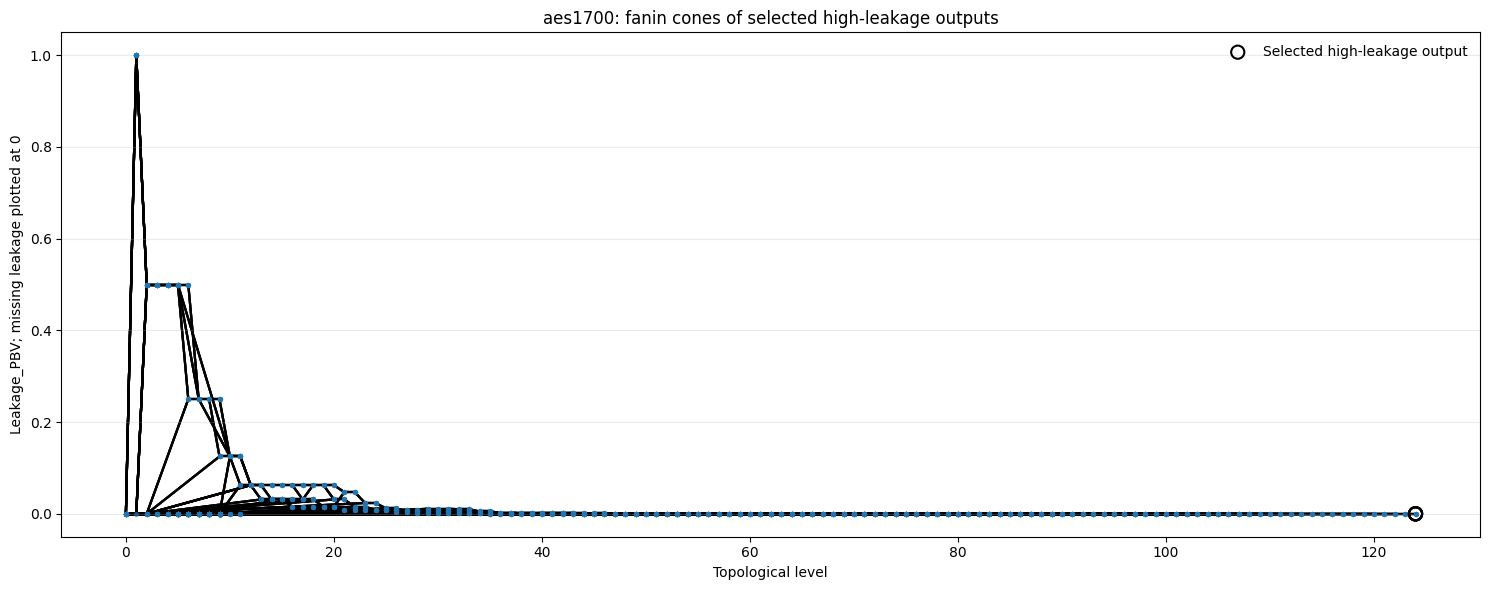

aes1700: fanin-only drawable_edges=2664, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1700/aes1700_fanin_only.png


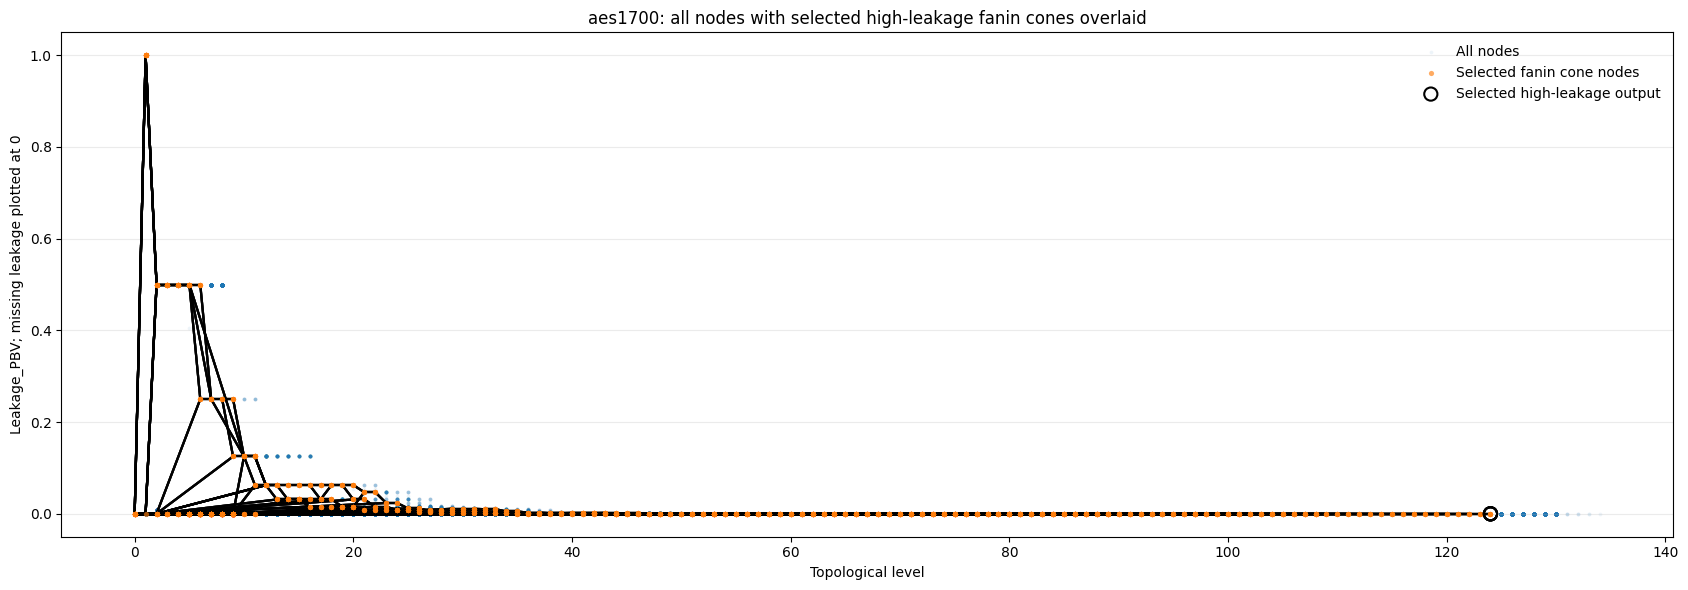

aes1700: full-overlay drawable_edges=2664, missing_edges=0, saved=fortify/analysis_outputs/leakage_topology/aes1700/aes1700_full_overlay.png


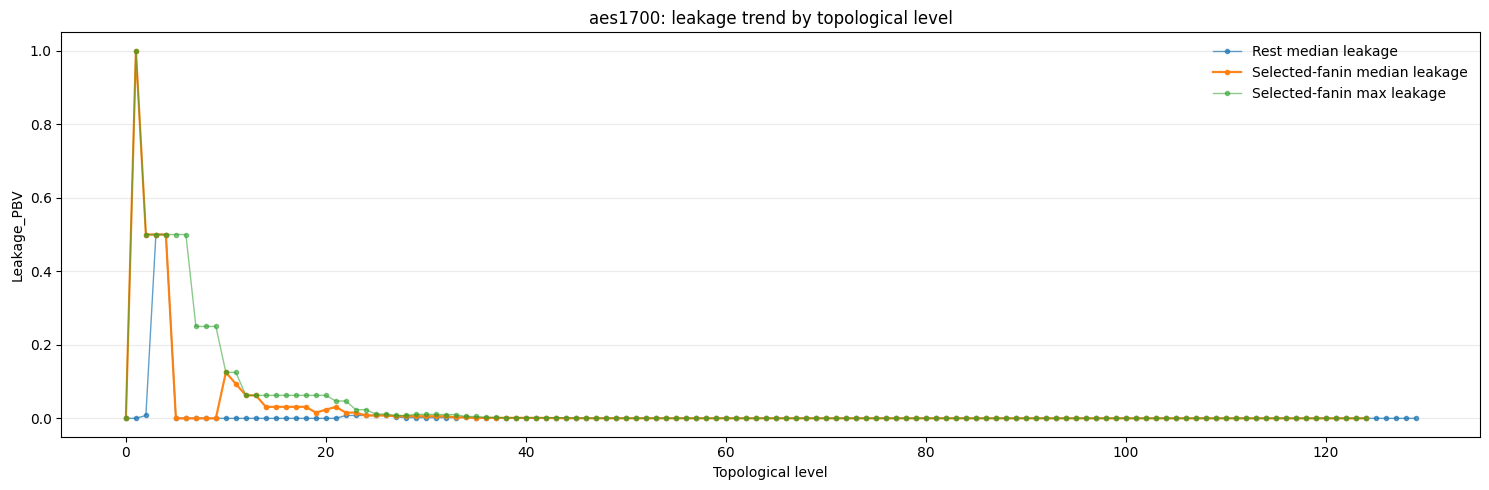

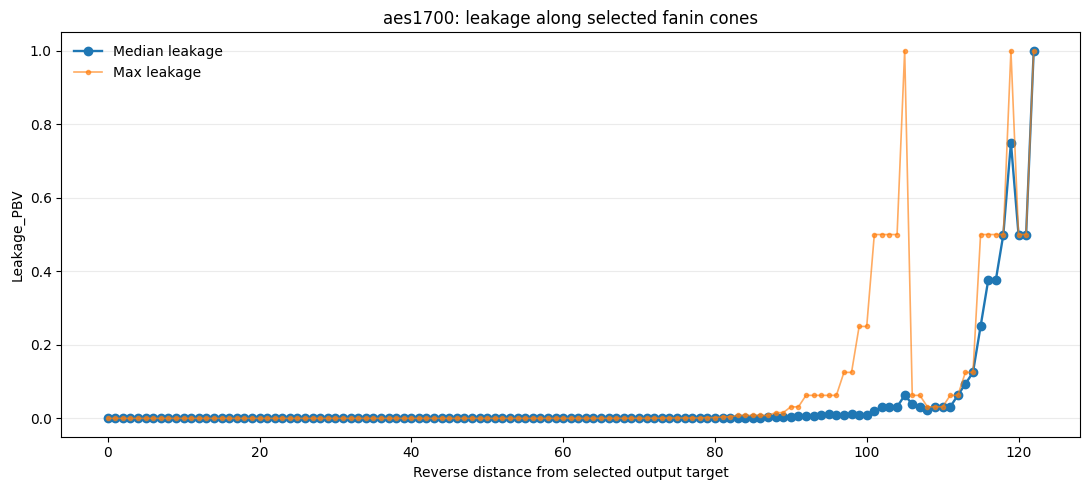

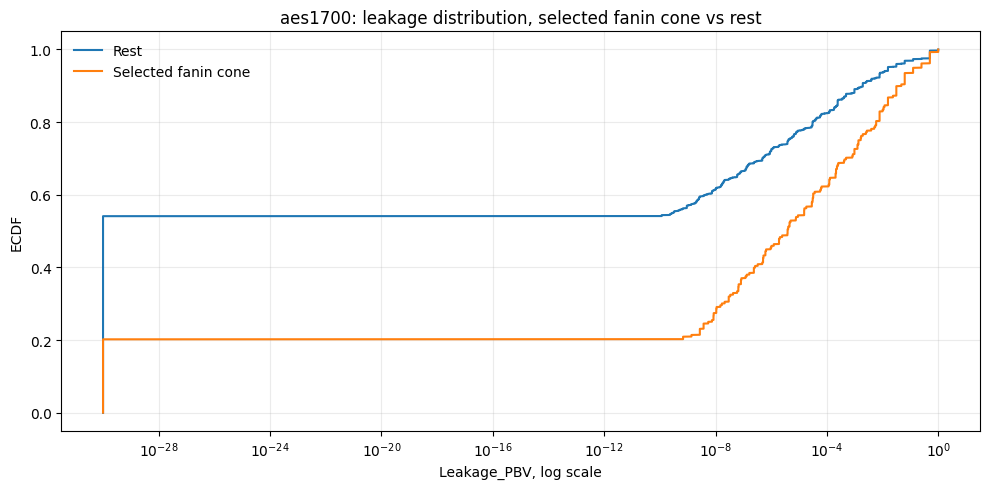

combined aes100: targets=5, cone_nodes=61, drawn_edges=111, missing_edges=0
combined aes200: targets=5, cone_nodes=83, drawn_edges=110, missing_edges=0
combined aes700: targets=5, cone_nodes=62, drawn_edges=131, missing_edges=0
combined aes800: targets=5, cone_nodes=86, drawn_edges=154, missing_edges=0
combined aes1100: targets=5, cone_nodes=86, drawn_edges=154, missing_edges=0
combined aes1200: targets=5, cone_nodes=82, drawn_edges=151, missing_edges=0
combined aes1600: targets=5, cone_nodes=2096, drawn_edges=2664, missing_edges=0
combined aes1700: targets=5, cone_nodes=2096, drawn_edges=2664, missing_edges=0


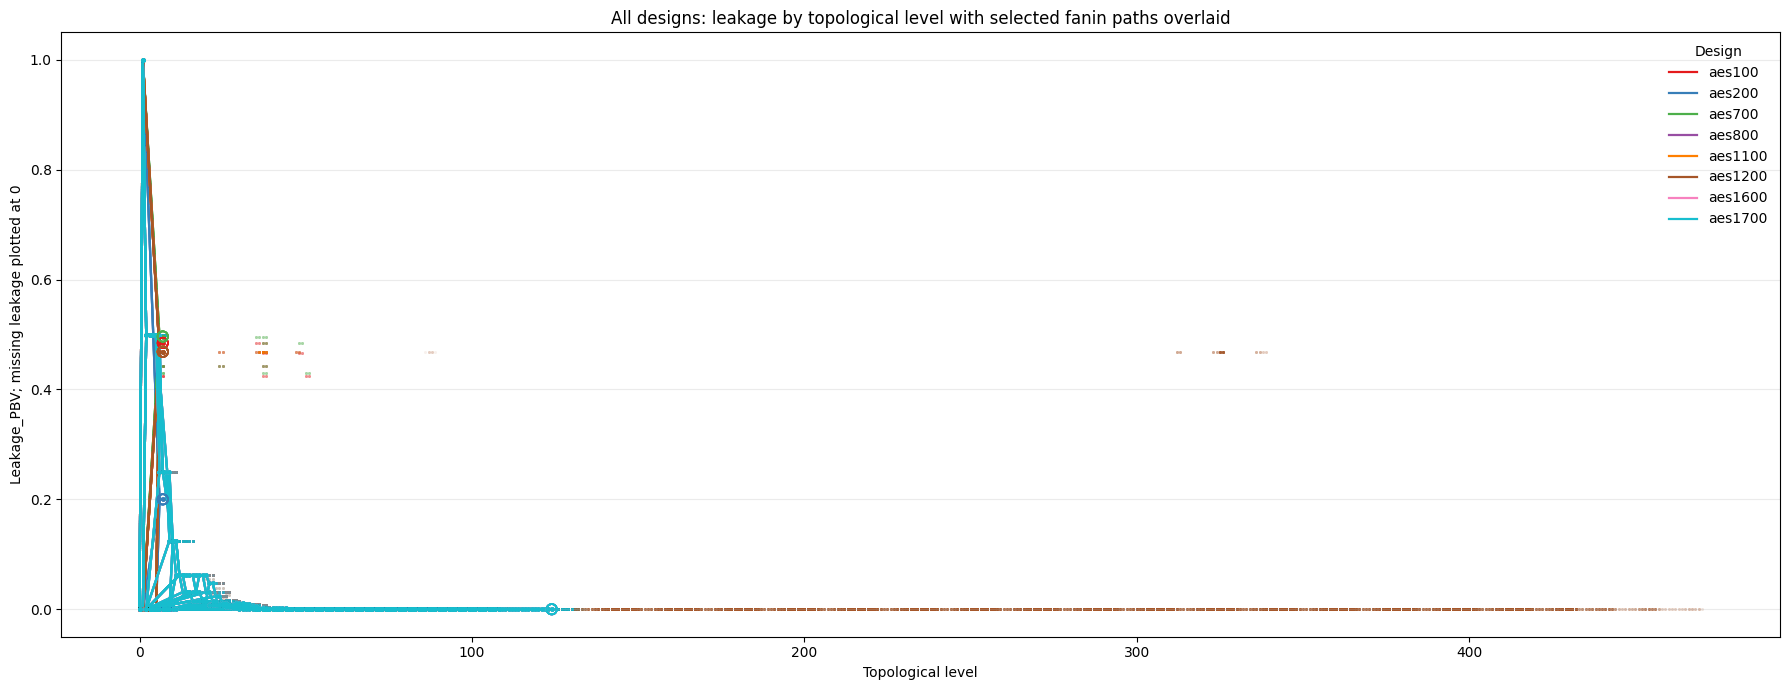

Saved combined plot to: fortify/analysis_outputs/leakage_topology/combined_full_overlay_by_design.png


,design,nodes,edges,is_raw_graph_dag,topological_levels,leakage_nodes,selected_targets,fanin_nodes,fanin_edges,fanin_leakage_nodes,rest_leakage_nodes,fanin_level_min,fanin_level_max,fanin_n,fanin_mean,fanin_std,fanin_min,fanin_p25,fanin_median,fanin_p75,fanin_p90,fanin_p95,fanin_p99,fanin_max,fanin_positive_log10_mean,rest_n,rest_mean,rest_std,rest_min,rest_p25,rest_median,rest_p75,rest_p90,rest_p95,rest_p99,rest_max,rest_positive_log10_mean,targets_n,targets_mean,targets_std,targets_min,targets_p25,targets_median,targets_p75,targets_p90,targets_p95,targets_p99,targets_max,targets_positive_log10_mean,auc_fanin_leakage_gt_rest,median_global_percentile_fanin,median_same_level_percentile_fanin,median_global_percentile_targets,median_same_level_percentile_targets,level_profile_mean_lift_cone_over_rest_median,level_profile_median_lift_cone_over_rest_median,level_profile_max_lift_cone_over_rest_median
0,aes100,80626,98310,False,122,76298,5,61,111,60,76238,0,7,60,0.097448,0.215232,0.0,0.000000e+00,0.000000,0.00000,0.484691,0.484691,0.695968,1.0,-0.285941,76238,0.018533,0.097671,0.0,0.0,0.0,0.000007,0.002513,0.031250,0.5,1.0,-4.817462,5,4.846909e-01,0.000000e+00,4.846909e-01,4.846909e-01,4.846909e-01,4.846909e-01,4.846909e-01,4.846909e-01,4.846909e-01,4.846909e-01,-0.314535,0.397641,0.267864,0.131503,0.974003,0.940964,0.318954,0.5,0.484691
1,aes200,78942,93958,True,130,78814,5,83,110,81,78733,0,7,81,0.049383,0.164897,0.0,0.000000e+00,0.000000,0.00000,0.200000,0.200000,1.000000,1.0,-0.582475,78733,0.016815,0.093224,0.0,0.0,0.0,0.000005,0.001953,0.031250,0.5,1.0,-5.019807,5,2.000000e-01,0.000000e+00,2.000000e-01,2.000000e-01,2.000000e-01,2.000000e-01,2.000000e-01,2.000000e-01,2.000000e-01,2.000000e-01,-0.698970,0.371421,0.266342,0.285714,0.972194,0.918398,0.097912,1.0,0.200000
2,aes700,80760,99303,False,122,76432,5,62,131,61,76371,0,7,61,0.097771,0.217325,0.0,0.000000e+00,0.000000,0.00000,0.496403,0.496403,0.697842,1.0,-0.276515,76371,0.018528,0.097722,0.0,0.0,0.0,0.000007,0.002513,0.031250,0.5,1.0,-4.818540,5,4.964026e-01,5.551115e-17,4.964026e-01,4.964026e-01,4.964026e-01,4.964026e-01,4.964026e-01,4.964026e-01,4.964026e-01,4.964026e-01,-0.304166,0.395851,0.268271,0.132565,0.974049,0.940964,0.403268,1.0,0.496403
3,aes800,83253,101792,False,130,78925,5,86,154,84,78841,0,7,84,0.079601,0.208854,0.0,0.000000e+00,0.000000,0.00000,0.468652,0.468652,1.000000,1.0,-0.274291,78841,0.020251,0.101836,0.0,0.0,0.0,0.000004,0.005890,0.031250,0.5,1.0,-4.767318,5,4.686520e-01,5.551115e-17,4.686520e-01,4.686520e-01,4.686520e-01,4.686520e-01,4.686520e-01,4.686520e-01,4.686520e-01,4.686520e-01,-0.329149,0.382263,0.283700,0.306566,0.969800,0.942156,0.500000,1.0,0.468652
4,aes1100,83253,102176,False,130,78925,5,86,154,84,78841,0,7,84,0.079601,0.208854,0.0,0.000000e+00,0.000000,0.00000,0.468652,0.468652,1.000000,1.0,-0.274291,78841,0.017955,0.096251,0.0,0.0,0.0,0.000006,0.001953,0.031250,0.5,1.0,-5.002376,5,4.686520e-01,5.551115e-17,4.686520e-01,4.686520e-01,4.686520e-01,4.686520e-01,4.686520e-01,4.686520e-01,4.686520e-01,4.686520e-01,-0.329149,0.367535,0.265860,0.136752,0.974666,0.942156,0.500000,1.0,0.468652
5,aes1200,120635,181987,False,471,76580,5,82,151,81,76499,0,7,81,0.070204,0.185829,0.0,0.000000e+00,0.000000,0.00000,0.468652,0.468652,0.574922,1.0,-0.299227,76499,0.018518,0.097725,0.0,0.0,0.0,0.000007,0.002513,0.031250,0.5,1.0,-4.818493,5,4.686520e-01,5.551115e-17,4.686520e-01,4.686520e-01,4.686520e-01,4.686520e-01,4.686520e-01,4.686520e-01,4.686520e-01,4.686520e-01,-0.329149,0.364661,0.268719,0.133621,0.974099,0.940984,0.403268,1.0,0.468652
6,aes1600,83259,536567,False,130,78686,5,2096,2664,2081,76605,0,124,2081,0.031746,0.123110,0.0,5.467303e-09,0.000004,0.00136,0.047119,0.250000,0.500000,1.0,-4.423504,76605,0.016154,0.092128,0.0,0.0,0.0,0.000004,0.001950,0.015625,0.5,1.0,-5.051120,5,6.834128e-10,0.000000e+00,6.834128e-10,6.834128e-10,6.834128e-10,6.834128e-10,6.834128e-10,6.834128e-10,6.834128e-10,6.834128e-10,-9.165317,0.694493,0.740233,0.563920,

In [29]:
# -----------------------------
# Run all designs and create combined plot
# -----------------------------
# After tuning the config above, run this cell.

all_bundles = []
errors = []

for idx, spec in enumerate(DESIGN_SPECS):
    try:
        bundle = analyze_design(spec, design_index=idx)
        all_bundles.append(bundle)
    except Exception as exc:
        errors.append((spec["design"], str(exc)))
        print(f"Skipping {spec['design']}: {exc}")

combined_plot = plot_combined_full_overlay(all_bundles)

summary_df = pd.DataFrame([b["stats"] for b in all_bundles])
summary_df.to_csv(OUTPUT_ROOT / "analysis_summary.csv", index=False)

if errors:
    errors_df = pd.DataFrame(errors, columns=["design", "error"])
    errors_df.to_csv(OUTPUT_ROOT / "analysis_errors.csv", index=False)
    display(errors_df)

display(summary_df)


In [30]:
# -----------------------------
# Optional: compare target and path statistics across all completed designs
# -----------------------------

bundles_for_tables = all_bundles if "all_bundles" in globals() and all_bundles else [one_bundle]

target_tables = []
level_profiles = []
distance_profiles = []

for b in bundles_for_tables:
    tdf = b["target_df"].copy()
    tdf["design"] = b["design"]
    target_tables.append(tdf)

    lp = b["level_profile"].copy()
    if not lp.empty:
        lp["design"] = b["design"]
        level_profiles.append(lp)

    dp = b["distance_profile"].copy()
    if not dp.empty:
        dp["design"] = b["design"]
        distance_profiles.append(dp)

if target_tables:
    all_targets_df = pd.concat(target_tables, ignore_index=True)
    all_targets_df.to_csv(OUTPUT_ROOT / "all_selected_targets.csv", index=False)
    display(all_targets_df.sort_values(["leakage"], ascending=False).head(100))

if level_profiles:
    all_level_profiles_df = pd.concat(level_profiles, ignore_index=True)
    all_level_profiles_df.to_csv(OUTPUT_ROOT / "all_level_profiles_cone_vs_rest.csv", index=False)
    display(all_level_profiles_df.head(50))

if distance_profiles:
    all_distance_profiles_df = pd.concat(distance_profiles, ignore_index=True)
    all_distance_profiles_df.to_csv(OUTPUT_ROOT / "all_distance_profiles_inside_fanin.csv", index=False)
    display(all_distance_profiles_df.head(50))


,design,node,topological_level,scc_size,indegree,outdegree,has_leakage,leakage,plot_leakage,best_ref,actual_signal,actual_ref,pbv,prior,leakage_percentile_global,leakage_percentile_same_level,leakage_log10,output_like_robust_z,is_selected_target,in_selected_fanin_cone,fanin_min_distance_to_target,fanin_targets_reached
12,aes700,top.Capacitance[12:12],7,1,1,0,True,4.964026e-01,4.964026e-01,top.key[1:1],top.Capacitance[12:12]@20,top.key[1:1],0.748201,0.5,0.974049,0.940964,-0.304166,8.801875e-01,True,True,0,1
13,aes700,top.Capacitance[13:13],7,1,1,0,True,4.964026e-01,4.964026e-01,top.key[1:1],top.Capacitance[13:13]@20,top.key[1:1],0.748201,0.5,0.974049,0.940964,-0.304166,8.801875e-01,True,True,0,1
10,aes700,top.Capacitance[10:10],7,1,1,0,True,4.964026e-01,4.964026e-01,top.key[1:1],top.Capacitance[10:10]@20,top.key[1:1],0.748201,0.5,0.974049,0.940964,-0.304166,8.801875e-01,True,True,0,1
14,aes700,top.Capacitance[15:15],7,1,1,0,True,4.964026e-01,4.964026e-01,top.key[1:1],top.Capacitance[15:15]@20,top.key[1:1],0.748201,0.5,0.974049,0.940964,-0.304166,8.801875e-01,True,True,0,1
11,aes700,top.Capacitance[11:11],7,1,1,0,True,4.964026e-01,4.964026e-01,top.key[1:1],top.Capacitance[11:11]@20,top.key[1:1],0.748201,0.5,0.974049,0.940964,-0.304166,8.801875e-01,True,True,0,1
0,aes100,top.Capacitance[10:10],7,1,1,0,True,4.846909e-01,4.846909e-01,top.key[1:1],top.Capacitance[10:10]@20,top.key[1:1],0.742345,0.5,0.974003,0.940964,-0.314535,8.661500e-01,True,True,0,1
2,aes100,top.Capacitance[12:12],7,1,1,0,True,4.846909e-01,4.846909e-01,top.key[1:1],top.Capacitance[12:12]@20,top.key[1:1],0.742345,0.5,0.974003,0.940964,-0.314535,8.661500e-01,True,True,0,1
1,aes100,top.Capacitance[11:11],7,1,1,0,True,4.846909e-01,4.846909e-01,top.key[1:1],top.Capacitance[11:11]@20,top.key[1:1],0.742345,0.5,0.974003,0.940964,-0.314535,8.661500e-01,True,True,0,1
3,aes100,top.Capacitance[13:13],7,1,1,0,True,4.846909e-01,4.846909e-01,top.key[1:1],top.Capacitance[13:13]@20,top.key[1:1],0.742345,0.5,0.974003,0.940964,-0.314535,8.661500e-01,True,True,0,1
4,aes100,top.Capacitance[15:15],7,1,1,0,True,4.846909e-01,4.846909e-01,top.key[1:1],top.Capacitance[15:15]@20,top.key[1:1],0.742345,0.5,0.974003,0.940964,-0.314535,8.661500e-01,True,True,0,1


,topological_level,count_fanin_cone,count_rest,mean_fanin_cone,mean_rest,median_fanin_cone,median_rest,max_fanin_cone,max_rest,mean_lift_cone_over_rest,median_lift_cone_over_rest,max_lift_cone_over_rest,design
0,0,2.0,556.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,aes100
1,1,3.0,488.0,0.333333,0.522541,0.000000,1.000000,1.000000,1.000000,6.379085e-01,1.000000e-30,1.000000e+00,aes100
2,2,2.0,299.0,0.000000,0.428094,0.000000,0.500000,0.000000,0.500000,2.335938e-30,2.000000e-30,2.000000e-30,aes100
3,3,41.0,305.0,0.000000,0.419672,0.000000,0.500000,0.000000,0.500000,2.382813e-30,2.000000e-30,2.000000e-30,aes100
4,4,1.0,460.0,0.000000,0.278261,0.000000,0.500000,0.000000,0.500000,3.593750e-30,2.000000e-30,2.000000e-30,aes100
5,5,1.0,916.0,0.000000,0.157205,0.000000,0.000000,0.000000,0.500000,6.361111e-30,1.000000e+00,2.000000e-30,aes100
6,6,5.0,2900.0,0.484691,0.044368,0.484691,0.000000,0.484691,0.500000,1.092432e+01,4.846909e+29,9.693817e-01,aes100
7,7,5.0,2900.0,0.484691,0.042299,0.484691,0.000000,0.484691,0.500000,1.145866e+01,4.846909e+29,9.693817e-01,aes100
8,8,NaN,5257.0,NaN,0.029675,NaN,0.000000,NaN,0.500000,NaN,NaN,NaN,aes100
9,9,NaN,5953.0,NaN,0.002184,NaN,0.000000,NaN,0.250000,NaN,NaN,NaN,aes100


,distance_to_selected_target,count,mean,median,max,design
0,0,5,0.484691,0.484691,0.484691,aes100
1,1,5,0.484691,0.484691,0.484691,aes100
2,2,3,0.333333,0.000000,1.000000,aes100
3,3,2,0.000000,0.000000,0.000000,aes100
4,4,1,0.000000,0.000000,0.000000,aes100
5,5,3,0.000000,0.000000,0.000000,aes100
6,6,2,0.000000,0.000000,0.000000,aes100
7,7,2,0.000000,0.000000,0.000000,aes100
8,8,1,0.000000,0.000000,0.000000,aes100
9,9,1,0.000000,0.000000,0.000000,aes100
